In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nfl-big-data-bowl-2026-prediction/test_input.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/test.csv
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/nfl_inference_server.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/nfl_gateway.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/__init__.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/templates.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/base_gateway.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/relay.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/__init__.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py
/kaggle/input/nfl-big-data-bowl-2026-prediction/kaggle_evaluation/core/generated/kaggle_evaluati

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
warnings.filterwarnings('ignore')

# ============================================================================
# GPU CONFIGURATION & OPTIMIZATION
# ============================================================================

def setup_gpu():
    """Configure GPU for optimal performance"""
    print("="*80)
    print("GPU CONFIGURATION")
    print("="*80)
    
    # Check available GPUs
    gpus = tf.config.list_physical_devices('GPU')
    print(f"\n🖥️  Available GPUs: {len(gpus)}")
    
    if gpus:
        try:
            # Enable memory growth (don't allocate all GPU memory at once)
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
                print(f"   ✓ GPU: {gpu.name} - Memory growth enabled")
            
            # Set GPU memory limit (optional - useful if sharing GPU)
            # tf.config.set_logical_device_configuration(
            #     gpus[0],
            #     [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]  # 4GB
            # )
            
            # Use mixed precision for faster training
            policy = tf.keras.mixed_precision.Policy('mixed_float16')
            tf.keras.mixed_precision.set_global_policy(policy)
            print(f"   ✓ Mixed precision enabled: {policy.name}")
            
            logical_gpus = tf.config.list_logical_devices('GPU')
            print(f"   ✓ Logical GPUs: {len(logical_gpus)}")
            
        except RuntimeError as e:
            print(f"   ⚠️  GPU configuration error: {e}")
    else:
        print("   ⚠️  No GPU found - using CPU (training will be slower)")
    
    # Set TensorFlow options for better performance
    tf.config.optimizer.set_jit(True)  # XLA compilation
    print("   ✓ XLA (Accelerated Linear Algebra) enabled")
    
    print(f"\n📊 TensorFlow version: {tf.__version__}")
    print(f"📊 Keras version: {keras.__version__}")
    
    return len(gpus) > 0

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'sequence_length': 10,
    'max_frames_to_predict': 15,
    'batch_size': 256,  # Larger batch for GPU
    'epochs': 100,
    'learning_rate': 0.001,
    'validation_split': 0.15,
    'use_gpu': True,
}

# ============================================================================
# EVALUATION METRICS
# ============================================================================

def calculate_rmse(y_true, y_pred):
    """Calculate Root Mean Squared Error"""
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    return rmse

def calculate_mae(y_true, y_pred):
    """Calculate Mean Absolute Error"""
    mae = np.mean(np.abs(y_true - y_pred))
    return mae

def calculate_euclidean_distance(y_true, y_pred):
    """Calculate Euclidean distance between predicted and actual positions"""
    distances = np.sqrt((y_true[:, 0] - y_pred[:, 0])**2 + 
                       (y_true[:, 1] - y_pred[:, 1])**2)
    return distances

def evaluate_predictions(y_true, y_pred, split_name="Validation"):
    """Comprehensive evaluation of predictions"""
    print("\n" + "="*80)
    print(f"📊 {split_name.upper()} SET EVALUATION")
    print("="*80)
    
    # Overall metrics
    x_rmse = calculate_rmse(y_true[:, 0], y_pred[:, 0])
    y_rmse = calculate_rmse(y_true[:, 1], y_pred[:, 1])
    
    x_mae = calculate_mae(y_true[:, 0], y_pred[:, 0])
    y_mae = calculate_mae(y_true[:, 1], y_pred[:, 1])
    
    # Euclidean distance
    distances = calculate_euclidean_distance(y_true, y_pred)
    mean_distance = np.mean(distances)
    median_distance = np.median(distances)
    
    print(f"\n🎯 POSITION ACCURACY:")
    print(f"   X-coordinate:")
    print(f"      RMSE: {x_rmse:.3f} yards")
    print(f"      MAE:  {x_mae:.3f} yards")
    
    print(f"\n   Y-coordinate:")
    print(f"      RMSE: {y_rmse:.3f} yards")
    print(f"      MAE:  {y_mae:.3f} yards")
    
    print(f"\n📏 EUCLIDEAN DISTANCE:")
    print(f"   Mean:   {mean_distance:.3f} yards")
    print(f"   Median: {median_distance:.3f} yards")
    print(f"   Std:    {np.std(distances):.3f} yards")
    print(f"   Min:    {np.min(distances):.3f} yards")
    print(f"   Max:    {np.max(distances):.3f} yards")
    
    # Percentiles
    print(f"\n📊 DISTANCE PERCENTILES:")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"   {p}th percentile: {np.percentile(distances, p):.3f} yards")
    
    # Accuracy buckets
    print(f"\n🎯 ACCURACY BUCKETS:")
    for threshold in [1, 2, 5, 10, 15, 20]:
        within = (distances <= threshold).sum()
        pct = 100 * within / len(distances)
        print(f"   Within {threshold:2d} yards: {within:6,} ({pct:5.2f}%)")
    
    metrics = {
        'x_rmse': x_rmse,
        'y_rmse': y_rmse,
        'x_mae': x_mae,
        'y_mae': y_mae,
        'mean_distance': mean_distance,
        'median_distance': median_distance,
        'distances': distances
    }
    
    return metrics

def plot_predictions(y_true, y_pred, split_name="Validation", save_path="predictions_plot.png"):
    """Visualize predictions vs actual"""
    
    fig = plt.figure(figsize=(20, 12))
    
    # 1. X predictions scatter
    ax1 = plt.subplot(2, 3, 1)
    ax1.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.3, s=1)
    ax1.plot([0, 120], [0, 120], 'r--', linewidth=2)
    ax1.set_xlabel('Actual X (yards)', fontsize=12)
    ax1.set_ylabel('Predicted X (yards)', fontsize=12)
    ax1.set_title(f'{split_name} - X Coordinate', fontsize=14, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # 2. Y predictions scatter
    ax2 = plt.subplot(2, 3, 2)
    ax2.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.3, s=1)
    ax2.plot([0, 53.3], [0, 53.3], 'r--', linewidth=2)
    ax2.set_xlabel('Actual Y (yards)', fontsize=12)
    ax2.set_ylabel('Predicted Y (yards)', fontsize=12)
    ax2.set_title(f'{split_name} - Y Coordinate', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    # 3. Error distribution
    ax3 = plt.subplot(2, 3, 3)
    distances = calculate_euclidean_distance(y_true, y_pred)
    ax3.hist(distances, bins=50, alpha=0.7, edgecolor='black')
    ax3.axvline(np.mean(distances), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(distances):.2f}')
    ax3.set_xlabel('Euclidean Distance Error (yards)', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 4. X error distribution
    ax4 = plt.subplot(2, 3, 4)
    x_errors = y_true[:, 0] - y_pred[:, 0]
    ax4.hist(x_errors, bins=50, alpha=0.7, edgecolor='black', color='green')
    ax4.axvline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_xlabel('X Error (yards)', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.set_title(f'X Error - Mean: {np.mean(x_errors):.3f}', fontsize=14, fontweight='bold')
    ax4.grid(alpha=0.3)
    
    # 5. Y error distribution
    ax5 = plt.subplot(2, 3, 5)
    y_errors = y_true[:, 1] - y_pred[:, 1]
    ax5.hist(y_errors, bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax5.axvline(0, color='red', linestyle='--', linewidth=2)
    ax5.set_xlabel('Y Error (yards)', fontsize=12)
    ax5.set_ylabel('Frequency', fontsize=12)
    ax5.set_title(f'Y Error - Mean: {np.mean(y_errors):.3f}', fontsize=14, fontweight='bold')
    ax5.grid(alpha=0.3)
    
    # 6. Cumulative accuracy
    ax6 = plt.subplot(2, 3, 6)
    sorted_distances = np.sort(distances)
    cumulative = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances) * 100
    ax6.plot(sorted_distances, cumulative, linewidth=2)
    ax6.set_xlabel('Distance Threshold (yards)', fontsize=12)
    ax6.set_ylabel('Cumulative % of Predictions', fontsize=12)
    ax6.set_title('Cumulative Accuracy Curve', fontsize=14, fontweight='bold')
    ax6.grid(alpha=0.3)
    
    # Add benchmarks
    for threshold in [5, 10, 15]:
        pct = (distances <= threshold).sum() / len(distances) * 100
        ax6.axvline(threshold, linestyle='--', alpha=0.5)
        ax6.text(threshold, pct, f'{pct:.1f}%', fontsize=10)
    
    plt.suptitle(f'{split_name} Set - Prediction Analysis', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved plot: {save_path}")
    
    return fig

def plot_training_history(history, save_path="training_history.png"):
    """Plot training history"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # MAE plot
    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE (yards)', fontsize=12)
    axes[1].set_title('Training and Validation MAE', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved plot: {save_path}")
    
    return fig

# ============================================================================
# IMPORT FUNCTIONS FROM ORIGINAL CODE
# ============================================================================

def parse_height(height_str):
    if pd.isna(height_str):
        return np.nan
    try:
        feet, inches = map(int, str(height_str).split('-'))
        return feet * 12 + inches
    except:
        return np.nan

def calculate_age(birth_date, reference_date='2023-09-01'):
    try:
        birth = pd.to_datetime(birth_date)
        ref = pd.to_datetime(reference_date)
        return (ref - birth).days / 365.25
    except:
        return np.nan

def load_training_data(data_path='/kaggle/input/nfl-big-data-bowl-2026-prediction/train'):
    print("\n" + "="*80)
    print("LOADING TRAINING DATA")
    print("="*80)
    
    all_data = []
    for week in range(1, 19):
        file_path = f'{data_path}/input_2023_w{week:02d}.csv'
        try:
            df = pd.read_csv(file_path)
            all_data.append(df)
            print(f"✓ Week {week:02d}: {len(df):,} rows | {df['play_id'].nunique():,} plays")
        except FileNotFoundError:
            print(f"✗ Week {week:02d}: File not found")
    
    train_df = pd.concat(all_data, ignore_index=True)
    print(f"\nTotal training data: {len(train_df):,} rows")
    print(f" Unique plays: {(train_df['game_id'].astype(str) + '_' + train_df['play_id'].astype(str)).nunique():,}")
    print(f"Players to predict: {train_df['player_to_predict'].sum():,}")
    
    return train_df

def load_test_data():
    print("\n" + "="*80)
    print("LOADING TEST DATA")
    print("="*80)
    
    test_input = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/test_input.csv')
    test_targets = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2026-prediction/test.csv')
    
    print(f"✓ Test input: {len(test_input):,} rows")
    print(f"✓ Test targets: {len(test_targets):,} predictions needed")
    
    return test_input, test_targets

def normalize_play_direction(df):
    df = df.copy()
    left_mask = df['play_direction'] == 'left'
    num_flipped = left_mask.sum()
    
    df.loc[left_mask, 'x'] = 120 - df.loc[left_mask, 'x']
    df.loc[left_mask, 'y'] = 53.3 - df.loc[left_mask, 'y']
    df.loc[left_mask, 'dir'] = (df.loc[left_mask, 'dir'] + 180) % 360
    df.loc[left_mask, 'o'] = (df.loc[left_mask, 'o'] + 180) % 360
    
    if 'ball_land_x' in df.columns:
        df.loc[left_mask, 'ball_land_x'] = 120 - df.loc[left_mask, 'ball_land_x']
        df.loc[left_mask, 'ball_land_y'] = 53.3 - df.loc[left_mask, 'ball_land_y']
    
    print(f"   Normalized {num_flipped:,} plays moving left → right")
    return df

def engineer_features(df):
    print("\n" + "="*80)
    print("FEATURE ENGINEERING")
    print("="*80)
    
    df = df.copy()
    
    print("✓ Computing velocity components (vx, vy)")
    df['vx'] = df['s'] * np.cos(np.radians(df['dir']))
    df['vy'] = df['s'] * np.sin(np.radians(df['dir']))
    
    print("✓ Computing orientation components (ox, oy)")
    df['ox'] = np.cos(np.radians(df['o']))
    df['oy'] = np.sin(np.radians(df['o']))
    
    if 'ball_land_x' in df.columns:
        print("✓ Computing ball landing features")
        df['dist_to_ball'] = np.sqrt(
            (df['x'] - df['ball_land_x'])**2 + 
            (df['y'] - df['ball_land_y'])**2
        )
        df['angle_to_ball'] = np.arctan2(
            df['ball_land_y'] - df['y'],
            df['ball_land_x'] - df['x']
        )
        df['vel_toward_ball'] = df['s'] * np.cos(np.radians(df['dir']) - df['angle_to_ball'])
    else:
        df['dist_to_ball'] = 0
        df['angle_to_ball'] = 0
        df['vel_toward_ball'] = 0
    
    print("✓ Computing field position features")
    df['dist_to_left_sideline'] = df['y']
    df['dist_to_right_sideline'] = 53.3 - df['y']
    df['dist_to_nearest_sideline'] = np.minimum(df['y'], 53.3 - df['y'])
    df['dist_to_endzone'] = 120 - df['x']
    
    print("✓ Processing player attributes")
    df['height_inches'] = df['player_height'].apply(parse_height)
    df['height_inches'] = df['height_inches'].fillna(df['height_inches'].median())
    
    df['player_age'] = df['player_birth_date'].apply(calculate_age)
    df['player_age'] = df['player_age'].fillna(df['player_age'].median())
    
    df['bmi'] = (df['player_weight'] * 703) / (df['height_inches'] ** 2)
    df['bmi'] = df['bmi'].fillna(df['bmi'].median())
    
    print("✓ Creating temporal features (lags, differences)")
    df = df.sort_values(['game_id', 'play_id', 'nfl_id', 'frame_id'])
    
    group_cols = ['game_id', 'play_id', 'nfl_id']
    for lag in [1, 2, 3]:
        for col in ['x', 'y', 's', 'a', 'vx', 'vy']:
            df[f'{col}_lag{lag}'] = df.groupby(group_cols)[col].shift(lag)
    
    df['speed_change'] = df.groupby(group_cols)['s'].diff()
    df['accel_change'] = df.groupby(group_cols)['a'].diff()
    df['dir_change'] = df.groupby(group_cols)['dir'].diff()
    
    df.loc[df['dir_change'] > 180, 'dir_change'] -= 360
    df.loc[df['dir_change'] < -180, 'dir_change'] += 360
    
    print("✓ Computing rolling statistics")
    for col in ['s', 'a']:
        df[f'{col}_roll_mean'] = df.groupby(group_cols)[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).mean()
        )
        df[f'{col}_roll_std'] = df.groupby(group_cols)[col].transform(
            lambda x: x.rolling(window=3, min_periods=1).std()
        )
    
    df = df.fillna(method='bfill').fillna(method='ffill').fillna(0)
    
    print(f"\n📊 Features created: {len(df.columns)} total columns")
    
    return df

def encode_categorical(df, encoders=None):
    df = df.copy()
    categorical_cols = ['player_position', 'player_side', 'player_role']
    
    if encoders is None:
        encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        return df, encoders
    else:
        for col in categorical_cols:
            if col in encoders:
                df[col] = df[col].astype(str).map(
                    lambda x: x if x in encoders[col].classes_ else encoders[col].classes_[0]
                )
                df[col] = encoders[col].transform(df[col])
        return df

def create_sequences(df, sequence_length=10, for_training=True):
    print("\n" + "="*80)
    print("CREATING SEQUENCES")
    print("="*80)
    
    sequence_features = [
        'x', 'y', 's', 'a', 'vx', 'vy', 'ox', 'oy', 'dir', 'o',
        'x_lag1', 'y_lag1', 's_lag1', 'a_lag1',
        'x_lag2', 'y_lag2', 's_lag2', 'a_lag2',
        'x_lag3', 'y_lag3', 's_lag3', 'a_lag3',
        'speed_change', 'accel_change', 'dir_change',
        's_roll_mean', 'a_roll_mean',
        'dist_to_left_sideline', 'dist_to_right_sideline', 'dist_to_nearest_sideline'
    ]
    
    static_features = [
        'player_position', 'player_side', 'player_role',
        'height_inches', 'player_weight', 'player_age', 'bmi',
        'absolute_yardline_number', 'dist_to_ball', 'angle_to_ball'
    ]
    
    sequences = []
    static_data = []
    targets = []
    metadata = []
    
    grouped = df.groupby(['game_id', 'play_id', 'nfl_id'])
    
    for (game_id, play_id, nfl_id), group in grouped:
        if for_training and not group['player_to_predict'].any():
            continue
        
        group = group.sort_values('frame_id')
        
        if len(group) < sequence_length:
            continue
        
        seq_data = group[sequence_features].iloc[-sequence_length:].values
        static = group[static_features].iloc[-1].values
        
        sequences.append(seq_data)
        static_data.append(static)
        
        if for_training and 'ball_land_x' in group.columns:
            target_x = group['ball_land_x'].iloc[-1]
            target_y = group['ball_land_y'].iloc[-1]
            targets.append([target_x, target_y])
        
        metadata.append({
            'game_id': game_id,
            'play_id': play_id,
            'nfl_id': nfl_id,
            'num_frames_output': group['num_frames_output'].iloc[-1] if 'num_frames_output' in group.columns else 0,
            'last_x': group['x'].iloc[-1],
            'last_y': group['y'].iloc[-1],
        })
    
    sequences = np.array(sequences, dtype=np.float32)
    static_data = np.array(static_data, dtype=np.float32)
    
    if for_training and len(targets) > 0:
        targets = np.array(targets, dtype=np.float32)
    else:
        targets = None
    
    print(f"✓ Created {len(sequences):,} sequences")
    print(f"✓ Sequence shape: {sequences.shape}")
    print(f"✓ Static shape: {static_data.shape}")
    if targets is not None:
        print(f"✓ Target shape: {targets.shape}")
    
    return sequences, static_data, targets, metadata

def build_model(sequence_shape, static_shape):
    print("\n" + "="*80)
    print("BUILDING MODEL")
    print("="*80)
    
    sequence_input = layers.Input(shape=sequence_shape, name='sequence_input')
    
    x = layers.LSTM(128, return_sequences=True)(sequence_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    static_input = layers.Input(shape=(static_shape,), name='static_input')
    s = layers.Dense(64, activation='relu')(static_input)
    s = layers.BatchNormalization()(s)
    s = layers.Dropout(0.2)(s)
    s = layers.Dense(32, activation='relu')(s)
    
    combined = layers.concatenate([x, s])
    
    z = layers.Dense(128, activation='relu')(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.3)(z)
    
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(0.2)(z)
    
    # For mixed precision, use float32 output
    output = layers.Dense(2, dtype='float32', name='position_output')(z)
    
    model = keras.Model(
        inputs=[sequence_input, static_input],
        outputs=output
    )
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
        loss='mse',
        metrics=['mae', 'mse']
    )
    
    model.summary()
    
    return model

def train_model(model, X_seq, X_static, y, validation_split=0.15):
    print("\n" + "="*80)
    print("TRAINING MODEL")
    print("="*80)
    
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    
    history = model.fit(
        [X_seq, X_static], y,
        batch_size=CONFIG['batch_size'],
        epochs=CONFIG['epochs'],
        validation_split=validation_split,
        callbacks=callbacks,
        verbose=1
    )
    
    return model, history

def create_submission(model, test_input, test_targets, metadata_lookup, scalers):
    print("\n" + "="*80)
    print("GENERATING PREDICTIONS")
    print("="*80)
    
    pred_dict = {}
    for meta, pred in zip(metadata_lookup, model.predict([test_input[0], test_input[1]], verbose=1)):
        key = (meta['game_id'], meta['play_id'], meta['nfl_id'])
        pred_dict[key] = {
            'x': pred[0],
            'y': pred[1],
            'last_x': meta['last_x'],
            'last_y': meta['last_y']
        }
    
    submissions = []
    for _, row in test_targets.iterrows():
        key = (row['game_id'], row['play_id'], row['nfl_id'])
        
        if key in pred_dict:
            x_pred = pred_dict[key]['x']
            y_pred = pred_dict[key]['y']
        else:
            x_pred = 60.0
            y_pred = 26.65
        
        submissions.append({
            'id': f"{row['game_id']}_{row['play_id']}_{row['nfl_id']}_{row['frame_id']}",
            'x': x_pred,
            'y': y_pred
        })
    
    submission_df = pd.DataFrame(submissions)
    submission_df.to_csv('submission.csv', index=False)
    
    print(f"✓ Submission created: {len(submission_df):,} predictions")
    print(f"✓ Saved to: submission.csv")
    
    return submission_df

# ============================================================================
# MAIN PIPELINE WITH EVALUATION
# ============================================================================
'''
def main():
    start_time = datetime.now()
    
    print("\n" + "="*80)
    print(" NFL BIG DATA BOWL 2026 - ENHANCED PIPELINE WITH EVALUATION")
    print("="*80)
    
    # Setup GPU
    has_gpu = setup_gpu()
    
    # Load data
    train_df = load_training_data()
    test_input_df, test_targets_df = load_test_data()
    
    # Preprocess
    print("\n📍 Step 1: Normalizing play direction...")
    train_df = normalize_play_direction(train_df)
    test_input_df = normalize_play_direction(test_input_df)
    
    # Feature engineering
    print("\n📍 Step 2: Feature engineering...")
    train_df = engineer_features(train_df)
    test_input_df = engineer_features(test_input_df)
    
    # Encode categorical
    print("\n📍 Step 3: Encoding categorical variables...")
    train_df, encoders = encode_categorical(train_df)
    test_input_df = encode_categorical(test_input_df, encoders)
    
    # Create sequences
    print("\n📍 Step 4: Creating sequences...")
    X_seq_all, X_static_all, y_all, metadata_all = create_sequences(
        train_df, CONFIG['sequence_length'], for_training=True
    )
    
    X_seq_test, X_static_test, _, metadata_test = create_sequences(
        test_input_df, CONFIG['sequence_length'], for_training=False
    )
    
    # Split train/validation
    print("\n📍 Step 5: Splitting train/validation...")
    n_samples = len(X_seq_all)
    n_val = int(n_samples * CONFIG['validation_split'])
    
    # Random shuffle
    indices = np.random.permutation(n_samples)
    train_idx = indices[n_val:]
    val_idx = indices[:n_val]
    
    X_seq_train = X_seq_all[train_idx]
    X_static_train = X_static_all[train_idx]
    y_train = y_all[train_idx]
    
    X_seq_val = X_seq_all[val_idx]
    X_static_val = X_static_all[val_idx]
    y_val = y_all[val_idx]
    
    print(f"   Training samples: {len(X_seq_train):,}")
    print(f"   Validation samples: {len(X_seq_val):,}")
    
    # Scale features
    print("\n📍 Step 6: Scaling features...")
    scaler_seq = StandardScaler()
    scaler_static = StandardScaler()
    
    # Scale sequence features
    X_seq_train_flat = X_seq_train.reshape(-1, X_seq_train.shape[-1])
    X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train_flat).reshape(X_seq_train.shape)
    
    X_seq_val_flat = X_seq_val.reshape(-1, X_seq_val.shape[-1])
    X_seq_val_scaled = scaler_seq.transform(X_seq_val_flat).reshape(X_seq_val.shape)
    
    # Scale static features
    X_static_train_scaled = scaler_static.fit_transform(X_static_train)
    X_static_val_scaled = scaler_static.transform(X_static_val)
    
    # Scale test features
    X_seq_test_flat = X_seq_test.reshape(-1, X_seq_test.shape[-1])
    X_seq_test_scaled = scaler_seq.transform(X_seq_test_flat).reshape(X_seq_test.shape)
    X_static_test_scaled = scaler_static.transform(X_static_test)
    
    # Build model
    print("\n📍 Step 7: Building model...")
    model = build_model(
        sequence_shape=(X_seq_train.shape[1], X_seq_train.shape[2]),
        static_shape=X_static_train.shape[1]
    )
    
    # Train model WITHOUT validation_split (we already split)
    print("\n📍 Step 8: Training model...")
    
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    
    history = model.fit(
        [X_seq_train_scaled, X_static_train_scaled], y_train,
        validation_data=([X_seq_val_scaled, X_static_val_scaled], y_val),
        batch_size=CONFIG['batch_size'],
        epochs=CONFIG['epochs'],
        callbacks=callbacks,
        verbose=1
    )
    
    # Plot training history
    print("\n📍 Step 9: Plotting training history...")
    plot_training_history(history, "training_history.png")
    
    # Evaluate on training set
    print("\n📍 Step 10: Evaluating on training set...")
    y_train_pred = model.predict([X_seq_train_scaled, X_static_train_scaled], verbose=0)
    train_metrics = evaluate_predictions(y_train, y_train_pred, "Training")
    plot_predictions(y_train, y_train_pred, "Training", "predictions_train.png")
    
    # Evaluate on validation set
    print("\n📍 Step 11: Evaluating on validation set...")
    y_val_pred = model.predict([X_seq_val_scaled, X_static_val_scaled], verbose=0)
    val_metrics = evaluate_predictions(y_val, y_val_pred, "Validation")
    plot_predictions(y_val, y_val_pred, "Validation", "predictions_val.png")
    
    # Save model and artifacts
    print("\n📍 Step 12: Saving model and artifacts...")
    model.save('nfl_model_final.keras')
    with open('scalers.pkl', 'wb') as f:
        pickle.dump({'seq': scaler_seq, 'static': scaler_static, 'encoders': encoders}, f)
    
    # Save metrics to file
    metrics_summary = {
        'training': {
            'x_rmse': float(train_metrics['x_rmse']),
            'y_rmse': float(train_metrics['y_rmse']),
            'x_mae': float(train_metrics['x_mae']),
            'y_mae': float(train_metrics['y_mae']),
            'mean_distance': float(train_metrics['mean_distance']),
            'median_distance': float(train_metrics['median_distance'])
        },
        'validation': {
            'x_rmse': float(val_metrics['x_rmse']),
            'y_rmse': float(val_metrics['y_rmse']),
            'x_mae': float(val_metrics['x_mae']),
            'y_mae': float(val_metrics['y_mae']),
            'mean_distance': float(val_metrics['mean_distance']),
            'median_distance': float(val_metrics['median_distance'])
        }
    }
    
    with open('metrics.pkl', 'wb') as f:
        pickle.dump(metrics_summary, f)
    
    # Create submission
    print("\n📍 Step 13: Creating submission...")
    submission = create_submission(
        model, 
        (X_seq_test_scaled, X_static_test_scaled),
        test_targets_df,
        metadata_test,
        {'seq': scaler_seq, 'static': scaler_static}
    )
    
    # Final summary
    end_time = datetime.now()
    duration = end_time - start_time
    
    print("\n" + "="*80)
    print("✅ PIPELINE COMPLETE!")
    print("="*80)
    
    print(f"\n⏱️  Total Time: {duration}")
    
    print(f"\n📁 Files created:")
    print(f"   • nfl_model_final.keras - Trained model")
    print(f"   • best_model.keras - Best model checkpoint")
    print(f"   • scalers.pkl - Feature scalers and encoders")
    print(f"   • metrics.pkl - Evaluation metrics")
    print(f"   • submission.csv - Final predictions ({len(submission):,} rows)")
    print(f"   • training_history.png - Training curves")
    print(f"   • predictions_train.png - Training set predictions")
    print(f"   • predictions_val.png - Validation set predictions")
    
    print(f"\n📊 FINAL RESULTS:")
    print(f"\n   Training Set:")
    print(f"      RMSE (X): {train_metrics['x_rmse']:.3f} yards")
    print(f"      RMSE (Y): {train_metrics['y_rmse']:.3f} yards")
    print(f"      Mean Distance Error: {train_metrics['mean_distance']:.3f} yards")
    
    print(f"\n   Validation Set:")
    print(f"      RMSE (X): {val_metrics['x_rmse']:.3f} yards")
    print(f"      RMSE (Y): {val_metrics['y_rmse']:.3f} yards")
    print(f"      Mean Distance Error: {val_metrics['mean_distance']:.3f} yards")
    
    print(f"\n🎯 Model Performance Summary:")
    within_5_val = (val_metrics['distances'] <= 5).sum() / len(val_metrics['distances']) * 100
    within_10_val = (val_metrics['distances'] <= 10).sum() / len(val_metrics['distances']) * 100
    print(f"   Predictions within 5 yards: {within_5_val:.1f}%")
    print(f"   Predictions within 10 yards: {within_10_val:.1f}%")
    
    print("\n" + "="*80)
    
    return model, history, submission, train_metrics, val_metrics

# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    model, history, submission, train_metrics, val_metrics = main()

'''

2025-12-04 14:16:47.108515: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764857807.309699      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764857807.369920      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'\ndef main():\n    start_time = datetime.now()\n    \n    print("\n" + "="*80)\n    print(" NFL BIG DATA BOWL 2026 - ENHANCED PIPELINE WITH EVALUATION")\n    print("="*80)\n    \n    # Setup GPU\n    has_gpu = setup_gpu()\n    \n    # Load data\n    train_df = load_training_data()\n    test_input_df, test_targets_df = load_test_data()\n    \n    # Preprocess\n    print("\n📍 Step 1: Normalizing play direction...")\n    train_df = normalize_play_direction(train_df)\n    test_input_df = normalize_play_direction(test_input_df)\n    \n    # Feature engineering\n    print("\n📍 Step 2: Feature engineering...")\n    train_df = engineer_features(train_df)\n    test_input_df = engineer_features(test_input_df)\n    \n    # Encode categorical\n    print("\n📍 Step 3: Encoding categorical variables...")\n    train_df, encoders = encode_categorical(train_df)\n    test_input_df = encode_categorical(test_input_df, encoders)\n    \n    # Create sequences\n    print("\n📍 Step 4: Creating sequences...")\

In [3]:
DF_NBL_PURE = load_training_data()


LOADING TRAINING DATA
✓ Week 01: 285,714 rows | 748 plays
✓ Week 02: 288,586 rows | 777 plays
✓ Week 03: 297,757 rows | 823 plays
✓ Week 04: 272,475 rows | 710 plays
✓ Week 05: 254,779 rows | 677 plays
✓ Week 06: 270,676 rows | 715 plays
✓ Week 07: 233,597 rows | 646 plays
✓ Week 08: 281,011 rows | 765 plays
✓ Week 09: 252,796 rows | 656 plays
✓ Week 10: 260,372 rows | 673 plays
✓ Week 11: 243,413 rows | 657 plays
✓ Week 12: 294,940 rows | 755 plays
✓ Week 13: 233,755 rows | 622 plays
✓ Week 14: 279,972 rows | 738 plays
✓ Week 15: 281,820 rows | 702 plays
✓ Week 16: 316,417 rows | 822 plays
✓ Week 17: 277,582 rows | 734 plays
✓ Week 18: 254,917 rows | 686 plays

Total training data: 4,880,579 rows
 Unique plays: 14,108
Players to predict: 1,303,440


In [4]:
from sklearn.preprocessing import LabelEncoder
!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q

# ============================================================================
# Cargar datos
# ============================================================================


# Muestra un número ilimitado de columnas
pd.set_option('display.max_columns', None)

# Muestra un ancho ilimitado para cada columna (para que no trunque el contenido)
pd.set_option('display.width', None)
print(".head")
print("###########################################################")
print(DF_NBL_PURE.head()) #informacion de cabecera-> util para ver ejemplo de 5 muestras
print(".info")
print("###########################################################")
print(DF_NBL_PURE.info()) #informacion general de data frame(muestra caracteristicas y tipo de dato) -> informacion de caracteristicas
print(".count")
print("###########################################################")
print(DF_NBL_PURE.count())#informacion de reconteo de datos por caracteristicas -> util para verificar datos perdidos tanto para hacer inputacion o o eliminacion de datos
print(".describe")
print("###########################################################")
print(DF_NBL_PURE.describe())


    


.head
###########################################################
      game_id  play_id  player_to_predict  nfl_id  frame_id play_direction  \
0  2023090700      101              False   54527         1          right   
1  2023090700      101              False   54527         2          right   
2  2023090700      101              False   54527         3          right   
3  2023090700      101              False   54527         4          right   
4  2023090700      101              False   54527         5          right   

   absolute_yardline_number player_name player_height  player_weight  \
0                        42  Bryan Cook           6-1            210   
1                        42  Bryan Cook           6-1            210   
2                        42  Bryan Cook           6-1            210   
3                        42  Bryan Cook           6-1            210   
4                        42  Bryan Cook           6-1            210   

  player_birth_date player_posit

In [5]:

data = DF_NBL_PURE.copy()
num_cols = data.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

data.head()


,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,player_birth_date,player_position,player_side,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,-0.320235,-1.681134,False,0.953508,-1.359540,right,-0.804465,Bryan Cook,6-1,-0.057639,1999-09-07,FS,Defense,Defensive Coverage,-0.347851,1.012183,-1.315063,-1.220753,1.408938,0.578552,1.755316,0.108481,-1.739696
1,-0.320235,-1.681134,False,0.953508,-1.269694,right,-0.804465,Bryan Cook,6-1,-0.057639,1999-09-07,FS,Defense,Defensive Coverage,-0.347851,1.012183,-1.337505,-1.065363,0.202478,0.556207,1.755316,0.108481,-1.739696
2,-0.320235,-1.681134,False,0.953508,-1.179847,right,-0.804465,Bryan Cook,6-1,-0.057639,1999-09-07,FS,Defense,Defensive Coverage,-0.347851,1.011184,-1.301597,-0.980605,-0.327129,0.602632,1.755316,0.108481,-1.739696
3,-0.320235,-1.681134,False,0.953508,-1.090000,right,-0.804465,Bryan Cook,6-1,-0.057639,1999-09-07,FS,Defense,Defensive Coverage,-0.346999,1.010184,-1.252224,-0.924100,-0.487481,0.639873,1.755316,0.108481,-1.739696
4,-0.320235,-1.681134,False,0.953508,-1.000154,right,-0.804465,Bryan Cook,6-1,-0.057639,1999-09-07,FS,Defense,Defensive Coverage,-0.346148,1.008186,-1.198363,-0.917037,-0.568302,0.639873,1.755316,0.108481,-1.739696


# Informacion Obtenida y exploracion

La base de datos contiene informacion de partidos del 2024 donde nos indican diferentes varibles de cada juego, el objetivo principal es predecir la posición del jugador en el campo (targets: x_aligned y y_aligned si existen; de lo contrario x y y). El tracking está a 10 Hz (≈ 10 fotogramas por segundo).
Informacion de cabecera metodo .head() -> Vimos ejemplo de informacion, util para ver de como se componen en forma de tabla

Informacion de caracteristicas metodo .info() -> podemos ver el tipo de datos por caracterisitca, definimos que puede ser importante para el modelo:

- Identificaciones: claves para uniones y para agrupar secuencias por jugador-jugada.
- game_id -> identificador único de cada partido
- play_id   -> identificador de jugada por cada partido
- nfl_id      -> id unico del jugador 
- frame_id-> Numero del fotograma de cada jugada, se registra con frecuencia de 10 Hz

Variables de posición 
- X - > posición de jugador en eje horizontal en yardas de 0 a 120
- Y - > posición de jugador en eje vertical en yardas de 0 a 53.3
- s -> Velocidad en yardas/segundos del jugador 
- a-> Aceleración en yardas/segundos^2 del jugador 
- dir-> dirección de moviento en grados (hacia donde se esta moviendo)
- o -> orientación (Hacia donde mira el jugador en grados)
- play_direction -> indica si la ofensiva ataca a la izquierda (left) o derecha (right)

- información/características de jugador:
- player_name -> Nombre del jugador
- player_height-> Altura del jugador
- player_weight-> Peso del jugador
- player_birth_date -> Edad 
- Player_posiition -> Rol típico (WR, CB, QB, etc.)
- player_side -> Ofensiva o defensiva.
- player_role -> Rol específico en esa jugada (pasador, receptor, cobertura, etc.)

Tratamiento de datos propuesta:

- Eliminacion de game_id, play_id: Estos datos pueden Generar que el modelo solo memorice o asimile por el identificador mas no generalice independientemente.
- Encoding de play_direction: 1 para derecha, -1 izquierda.
- Eliminacion de player_name: redundante ya que existe el id del jugador
- Transformaciones a pulgadas de player_height
- Transformacion a edad de player_birth_date
- Transformacion hot encoder de player_position
- Transformacion binaria player_side: 0 defensa 1 Ataque
- Transformacion label encodding de player_role
- Transformacion dir a dir_x = cos(dir) y dir_y = sin(dir) para evitar discontinuidad angular al igual 'o'


In [6]:
"""
===============================================================
Preprocessing Pipeline for NFL Player Tracking Data
===============================================================

Author: Juan Esteban
Description:
-------------
This script performs a complete preprocessing routine for NFL
player tracking data, preparing it for machine learning models.

The goal is to:
1. Clean and normalize spatial and temporal data.
2. Align all plays to a common field direction (→ right).
3. Convert categorical data to numeric formats.
4. Engineer meaningful physical and geometric features.
5. Ensure numerical stability and feature scaling.

Rationale:
-----------
In raw tracking data, plays may move left or right,
units differ (feet, inches, yards), and categories are text.
To make the dataset numerically consistent and comparable,
this pipeline standardizes all measurements and creates
physically meaningful representations.

Libraries:
-----------
- pandas / numpy: numerical and tabular operations
- sklearn: encoders and scalers for model readiness
- datetime: age computation
===============================================================
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from datetime import datetime


# ==============================================================
# === 1. COPY RAW DATA =========================================
# ==============================================================

data = DF_NBL_PURE.copy()


# ==============================================================
# === 2. BASIC CLEANING ========================================
# ==============================================================

"""
Remove columns that are not useful for modeling or contain unique IDs
(game_id, play_id, player_name). 'errors="ignore"' ensures robustness
in case these columns are missing.
"""
data.drop(columns=['game_id', 'play_id', 'player_name'], inplace=True, errors='ignore')


# ==============================================================
# === 3. PLAY DIRECTION CODING AND FIELD ALIGNMENT =============
# ==============================================================

"""
Convert 'play_direction' to numeric (right=1, left=-1) and reflect all
left-direction plays so that every play proceeds to the right.
This ensures consistent geometric reference for models.
"""

FIELD_LENGTH = 120.0  # yards
FIELD_WIDTH = 53.3    # yards

data['play_direction'] = np.where(
    data['play_direction'].astype(str).str.lower().str.strip() == 'right', 1,
    np.where(data['play_direction'].astype(str).str.lower().str.strip() == 'left', -1, np.nan)
)

# Reflect plays going left
data['x_aligned'] = np.where(data['play_direction'] == -1, FIELD_LENGTH - data['x'], data['x'])
data['y_aligned'] = np.where(data['play_direction'] == -1, FIELD_WIDTH - data['y'], data['y'])


# ==============================================================
# === 4. PLAYER HEIGHT NORMALIZATION ===========================
# ==============================================================

"""
Convert 'player_height' from '6-2' format (feet-inches) into total inches.
Using vectorized operations for efficiency.
"""
mask = data['player_height'].astype(str).str.contains('-', na=False)
split_heights = data.loc[mask, 'player_height'].str.extract(r'(\d+)-(\d+)').astype(float)
data.loc[mask, 'player_height'] = split_heights[0] * 12 + split_heights[1]
data['player_height'] = pd.to_numeric(data['player_height'], errors='coerce')


# ==============================================================
# === 5. PLAYER AGE CALCULATION ================================
# ==============================================================

"""
Compute player age in years using date of birth.
"""
data['player_birth_date'] = pd.to_datetime(data['player_birth_date'], errors='coerce')
today = pd.Timestamp(datetime.today())
data['player_age'] = (today - data['player_birth_date']).dt.days / 365.25
data.drop(columns=['player_birth_date'], inplace=True)


# ==============================================================
# === 6. PLAYER SIDE CODING ====================================
# ==============================================================

"""
Standardize player_side ('offense'=1, 'defense'=0).
Handles mixed string/integer encodings.
"""
if 'player_side' in data.columns:
    data['player_side'] = (
        data['player_side']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            'defense': 'defense',
            'def': 'defense',
            'offense': 'offense',
            'off': 'offense',
            '0': 'defense',
            '1': 'offense'
        })
        .map({'defense': 0, 'offense': 1})
    )


# ==============================================================
# === 7. POSITION ENCODING =====================================
# ==============================================================

"""
Combine rare positions (< 1000 samples) into a single 'OTHER' category
to reduce dimensionality and prevent sparse columns during one-hot encoding.
"""
position_counts = data['player_position'].value_counts()
rare_positions = position_counts.index[position_counts < 1000]
data['player_position'] = data['player_position'].where(~data['player_position'].isin(rare_positions), 'OTHER')

# One-Hot encode player positions
data = pd.get_dummies(data, columns=['player_position'], prefix='pos', dtype=int)


# ==============================================================
# === 8. PLAYER ROLE ENCODING ==================================
# ==============================================================

"""
If few unique roles, use one-hot; otherwise, label encode to numeric.
This balances expressiveness and compactness.
"""
if data['player_role'].nunique() <= 10:
    data = pd.get_dummies(data, columns=['player_role'], prefix='role', dtype=int)
else:
    le = LabelEncoder()
    data['player_role'] = le.fit_transform(data['player_role'].astype(str))


# ==============================================================
# === 9. ANGLE FEATURES (dir, o) ===============================
# ==============================================================

"""
Convert direction and orientation from degrees to radians and compute
unit vector components (cos, sin) for numerical stability in models.
Also compute angular difference (orientation - direction).
"""
for col in ['dir', 'o']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

rads = np.deg2rad(data[['dir', 'o']])
data['dir_x'], data['dir_y'] = np.cos(rads['dir']), np.sin(rads['dir'])
data['o_x'], data['o_y'] = np.cos(rads['o']), np.sin(rads['o'])
data['angle_diff'] = np.arctan2(
    np.sin(np.deg2rad(data['o'] - data['dir'])),
    np.cos(np.deg2rad(data['o'] - data['dir']))
)
data.drop(columns=['dir', 'o'], inplace=True)


# ==============================================================
# === 10. OUTLIER FILTERING ====================================
# ==============================================================

"""
Remove physically impossible values to prevent distortion.
Values are chosen based on reasonable physical limits observed in play data.
"""
data = data[
    (data['x_aligned'].between(0, FIELD_LENGTH)) &
    (data['y_aligned'].between(0, FIELD_WIDTH)) &
    (data['s'].between(0, 12)) &     # speed (yards/s) //Usain Bolt
    (data['a'].between(-5, 8))       # acceleration (yards/s²) //Usain Bolt
]


# ==============================================================
# === 11. ENGINEERED FEATURES ==================================
# ==============================================================

"""
Create additional informative features to help the model understand
spatial and kinematic relationships.
"""
# Velocity components
data['v_x'] = data['s'] * data['dir_x']
data['v_y'] = data['s'] * data['dir_y']

# Distance to field center
data['dist_center'] = np.abs(data['y_aligned'] - FIELD_WIDTH / 2)

# Normalized coordinates
data['x_norm'] = data['x_aligned'] / FIELD_LENGTH
data['y_norm'] = data['y_aligned'] / FIELD_WIDTH


# ==============================================================
# === 12. HANDLE NaN AND INFINITE VALUES =======================
# ==============================================================

"""
Replace infinities with NaN, drop essential missing rows,
and impute remaining missing numeric values with column means.
"""
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(subset=['s', 'a', 'x_aligned', 'y_aligned'], inplace=True)
data.fillna(data.mean(numeric_only=True), inplace=True)

 
# ==============================================================
# === 13. NUMERIC NORMALIZATION ================================
# ==============================================================

"""
Normalize all numeric features using StandardScaler (mean=0, std=1).
This improves model convergence, especially for gradient-based methods.
"""
num_cols = data.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])


# ==============================================================
# === 14. FINAL INFO ===========================================
# ==============================================================

data.info()
print("\n✅ Preprocessing complete: all plays aligned, normalized, and ready for modeling.")


<class 'pandas.core.frame.DataFrame'>
Index: 4879275 entries, 0 to 4880578
Data columns (total 48 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   player_to_predict         bool   
 1   nfl_id                    float64
 2   frame_id                  float64
 3   play_direction            float64
 4   absolute_yardline_number  float64
 5   player_height             float64
 6   player_weight             float64
 7   player_side               float64
 8   x                         float64
 9   y                         float64
 10  s                         float64
 11  a                         float64
 12  num_frames_output         float64
 13  ball_land_x               float64
 14  ball_land_y               float64
 15  x_aligned                 float64
 16  y_aligned                 float64
 17  player_age                float64
 18  pos_CB                    float64
 19  pos_DE                    float64
 20  pos_DT                    flo

In [7]:
# # 2. Calcular la matriz de correlación
# correlation_matrix = data.corr()

# # 3. Configurar el tamaño del gráfico
# plt.figure(figsize=(40, 40))

# # 4. Crear el mapa de calor con anotaciones y paleta de colores
# sns.heatmap(
#     correlation_matrix,
#     annot=True,        # Mostrar el valor numérico de la correlación en cada celda
#     cmap='coolwarm',   # Paleta de colores. 'coolwarm' es ideal para correlación (rojo/azul)
#     fmt=".2f",         # Formato para los números (2 decimales)
#     linewidths=.5,     # Líneas divisorias
#     cbar=True          # Mostrar la barra de color lateral
# )

# # 5. Añadir título y mostrar el gráfico
# plt.title('Mapa de Calor de la Matriz de Correlación')
# plt.show()

In [8]:
# data.hist(bins=50, figsize=(20,15))

In [9]:
print(data.count())

player_to_predict           4879275
nfl_id                      4879275
frame_id                    4879275
play_direction              4879275
absolute_yardline_number    4879275
player_height               4879275
player_weight               4879275
player_side                 4879275
x                           4879275
y                           4879275
s                           4879275
a                           4879275
num_frames_output           4879275
ball_land_x                 4879275
ball_land_y                 4879275
x_aligned                   4879275
y_aligned                   4879275
player_age                  4879275
pos_CB                      4879275
pos_DE                      4879275
pos_DT                      4879275
pos_FB                      4879275
pos_FS                      4879275
pos_ILB                     4879275
pos_MLB                     4879275
pos_NT                      4879275
pos_OLB                     4879275
pos_OTHER                   

# Modelos de regresion

## Linear Regresion

In [10]:
# # =========================================================
# # 🚀 MULTI-OUTPUT LINEAR REGRESSION (RAPIDS) CON MÉTRICAS COMPLETAS
# # =========================================================

# import cudf
# import cupy as cp
# from cuml.model_selection import train_test_split
# from cuml.linear_model import LinearRegression
# from cuml.metrics import r2_score, mean_squared_error, mean_absolute_error

# # =========================================================
# # 1️⃣ Convertir DataFrame de pandas a cuDF
# # =========================================================
# gdf = cudf.DataFrame.from_pandas(data)

# # =========================================================
# # 2️⃣ Separar variables de entrada (X) y salida (y)
# # =========================================================
# y = gdf[['x', 'y']]                 # Variables de salida
# X = gdf.drop(columns=['x', 'y'])    # Variables de entrada

# # =========================================================
# # 3️⃣ División de datos: 60% train / 20% valid / 20% test
# # =========================================================
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# print("📦 Tamaños de los conjuntos:")
# print(f"Entrenamiento: {len(X_train)}  |  Validación: {len(X_valid)}  |  Test: {len(X_test)}")

# # =========================================================
# # 4️⃣ Entrenamiento de modelos (uno para cada coordenada)
# # =========================================================
# model_x = LinearRegression()
# model_y = LinearRegression()

# model_x.fit(X_train, y_train['x'])
# model_y.fit(X_train, y_train['y'])

# # =========================================================
# # 5️⃣ Predicciones
# # =========================================================
# y_pred_valid_x = model_x.predict(X_valid)
# y_pred_valid_y = model_y.predict(X_valid)
# y_pred_test_x  = model_x.predict(X_test)
# y_pred_test_y  = model_y.predict(X_test)

# # =========================================================
# # 6️⃣ Función auxiliar para imprimir métricas
# # =========================================================
# def evaluar_modelo(y_true, y_pred, nombre=""):
#     mae = mean_absolute_error(y_true, y_pred)
#     mse = mean_squared_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     mape = cp.mean(cp.abs((y_true - y_pred) / y_true)) * 100  # en porcentaje
#     print(f"🔹 {nombre}:")
#     print(f"   MAE:  {mae:.4f}")
#     print(f"   MSE:  {mse:.4f}")
#     print(f"   R²:   {r2:.4f}")
#     print(f"   MAPE: {mape:.2f}%\n")

# # =========================================================
# # 7️⃣ Resultados de Validación
# # =========================================================
# print("\n📊 RESULTADOS VALIDACIÓN:")
# evaluar_modelo(y_valid['x'], y_pred_valid_x, "Coordenada X")
# evaluar_modelo(y_valid['y'], y_pred_valid_y, "Coordenada Y")

# # =========================================================
# # 8️⃣ Resultados de Test
# # =========================================================
# print("\n📊 RESULTADOS TEST:")
# evaluar_modelo(y_test['x'], y_pred_test_x, "Coordenada X")
# evaluar_modelo(y_test['y'], y_pred_test_y, "Coordenada Y")


## LASSO Regresor

In [11]:
# # =========================================================
# # ⚡ LASSO MULTI-OUTPUT (RAPIDS + OPTUNA BAYESIAN)
# # =========================================================
# import cupy as cp
# import optuna
# from cuml.linear_model import Lasso
# from cuml.metrics import r2_score, mean_squared_error, mean_absolute_error

# print("\n⚙️ Inicio del modelo LASSO con Optuna Bayesian...")

# # =========================================================
# # 1️⃣ Definir función objetivo para Optuna (optimización bayesiana)
# # =========================================================
# def objective(trial):
#     alpha = trial.suggest_float("alpha", 1e-5, 1.0, log=True)

#     # Modelos Lasso independientes para cada coordenada
#     model_x = Lasso(alpha=alpha, fit_intercept=True)
#     model_y = Lasso(alpha=alpha, fit_intercept=True)
    
#     model_x.fit(X_train, y_train['x'])
#     model_y.fit(X_train, y_train['y'])
    
#     # Predicciones en VALIDACIÓN
#     y_pred_x = model_x.predict(X_valid)
#     y_pred_y = model_y.predict(X_valid)
    
#     # Error cuadrático medio promedio
#     mse_x = mean_squared_error(y_valid['x'], y_pred_x)
#     mse_y = mean_squared_error(y_valid['y'], y_pred_y)
    
#     return float((mse_x + mse_y) / 2)

# # =========================================================
# # 2️⃣ Ejecutar búsqueda bayesiana (Optuna)
# # =========================================================
# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
# study.optimize(objective, n_trials=20, timeout=300)  # 20 pruebas máx o 5 minutos

# best_alpha = study.best_params['alpha']
# print(f"\n🔍 Mejor alpha encontrado: {best_alpha:.6f}")

# # =========================================================
# # 3️⃣ Entrenar modelo final con mejor alpha
# # =========================================================
# model_x = Lasso(alpha=best_alpha, fit_intercept=True)
# model_y = Lasso(alpha=best_alpha, fit_intercept=True)

# model_x.fit(X_train, y_train['x'])
# model_y.fit(X_train, y_train['y'])

# # =========================================================
# # 4️⃣ Función auxiliar para métricas completas
# # =========================================================
# def evaluar_modelo(y_true, y_pred, nombre=""):
#     mae = mean_absolute_error(y_true, y_pred)
#     mse = mean_squared_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     mape = cp.mean(cp.abs((y_true - y_pred) / y_true)) * 100
#     print(f"🔹 {nombre}:")
#     print(f"   MAE:  {mae:.4f}")
#     print(f"   MSE:  {mse:.4f}")
#     print(f"   R²:   {r2:.4f}")
#     print(f"   MAPE: {mape:.2f}%\n")

# # =========================================================
# # 5️⃣ Evaluar en VALIDACIÓN
# # =========================================================
# y_pred_valid_x = model_x.predict(X_valid)
# y_pred_valid_y = model_y.predict(X_valid)

# print("\n📊 RESULTADOS VALIDACIÓN:")
# evaluar_modelo(y_valid['x'], y_pred_valid_x, "Coordenada X")
# evaluar_modelo(y_valid['y'], y_pred_valid_y, "Coordenada Y")

# # =========================================================
# # 6️⃣ Evaluar en TEST
# # =========================================================
# y_pred_test_x = model_x.predict(X_test)
# y_pred_test_y = model_y.predict(X_test)

# print("\n📊 RESULTADOS TEST:")
# evaluar_modelo(y_test['x'], y_pred_test_x, "Coordenada X")
# evaluar_modelo(y_test['y'], y_pred_test_y, "Coordenada Y")


## Elasticnet Regresor

In [12]:
# # =========================================================
# # ⚡ ELASTICNET (RAPIDS + OPTUNA BAYESIAN)
# # =========================================================
# from cuml.linear_model import ElasticNet
# from cuml.metrics import r2_score, mean_squared_error, mean_absolute_error
# import cupy as cp
# import optuna

# print("\n⚙️ Inicio del modelo ElasticNet con Optuna Bayesian...")

# # =========================================================
# # 1️⃣ Función objetivo (usa las mismas variables en memoria GPU)
# # =========================================================
# def objective_elastic(trial):
#     alpha = trial.suggest_float("alpha", 1e-5, 1.0, log=True)
#     l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

#     model_x = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True, max_iter=5000)
#     model_y = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True, max_iter=5000)

#     model_x.fit(X_train, y_train['x'])
#     model_y.fit(X_train, y_train['y'])

#     # Predicciones en VALIDACIÓN
#     y_pred_x = model_x.predict(X_valid)
#     y_pred_y = model_y.predict(X_valid)

#     # Error cuadrático medio promedio
#     mse_x = mean_squared_error(y_valid['x'], y_pred_x)
#     mse_y = mean_squared_error(y_valid['y'], y_pred_y)
#     return float((mse_x + mse_y) / 2)

# # =========================================================
# # 2️⃣ Optimización Bayesiana con Optuna
# # =========================================================
# study_elastic = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
# study_elastic.optimize(objective_elastic, n_trials=25, timeout=300)

# best_params = study_elastic.best_params
# best_alpha = best_params['alpha']
# best_l1_ratio = best_params['l1_ratio']

# print(f"\n🔍 Mejor alpha: {best_alpha:.6f} | Mejor l1_ratio: {best_l1_ratio:.4f}")

# # =========================================================
# # 3️⃣ Entrenar modelos finales con los mejores parámetros
# # =========================================================
# model_x = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, fit_intercept=True, max_iter=5000)
# model_y = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, fit_intercept=True, max_iter=5000)

# model_x.fit(X_train, y_train['x'])
# model_y.fit(X_train, y_train['y'])

# # =========================================================
# # 4️⃣ Función de evaluación (igual que antes)
# # =========================================================
# def evaluar_modelo(y_true, y_pred, nombre=""):
#     mae = mean_absolute_error(y_true, y_pred)
#     mse = mean_squared_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     mape = cp.mean(cp.abs((y_true - y_pred) / y_true)) * 100
#     print(f"🔹 {nombre}:")
#     print(f"   MAE:  {mae:.4f}")
#     print(f"   MSE:  {mse:.4f}")
#     print(f"   R²:   {r2:.4f}")
#     print(f"   MAPE: {mape:.2f}%\n")

# # =========================================================
# # 5️⃣ Evaluar en VALIDACIÓN
# # =========================================================
# y_pred_valid_x = model_x.predict(X_valid)
# y_pred_valid_y = model_y.predict(X_valid)

# print("\n📊 RESULTADOS VALIDACIÓN (ElasticNet):")
# evaluar_modelo(y_valid['x'], y_pred_valid_x, "Coordenada X")
# evaluar_modelo(y_valid['y'], y_pred_valid_y, "Coordenada Y")

# # =========================================================
# # 6️⃣ Evaluar en TEST
# # =========================================================
# y_pred_test_x = model_x.predict(X_test)
# y_pred_test_y = model_y.predict(X_test)

# print("\n📊 RESULTADOS TEST (ElasticNet):")
# evaluar_modelo(y_test['x'], y_pred_test_x, "Coordenada X")
# evaluar_modelo(y_test['y'], y_pred_test_y, "Coordenada Y")


In [13]:
# # =========================================================
# # ⚡ KERNEL RIDGE MULTISALIDA OPTIMIZADO (GPU + Memoria)
# # =========================================================

# import cudf
# import cupy as cp
# import optuna
# from cuml.model_selection import train_test_split
# from cuml.metrics import r2_score
# from cuml.kernel_ridge import KernelRidge
# import gc

# # =========================================================
# # 1️⃣ Convertir DataFrame de pandas a cuDF y limpiar
# # =========================================================
# print("📥 Cargando datos...")
# gdf = cudf.DataFrame.from_pandas(data)
# gdf = gdf.dropna()
# print(f"✅ Datos cargados: {len(gdf):,} filas x {len(gdf.columns)} columnas")

# # =========================================================
# # 2️⃣ Separar variables
# # =========================================================
# y = gdf[['x', 'y']].astype('float32')  # Usar float32 para ahorrar memoria
# X = gdf.drop(columns=['x', 'y']).astype('float32')

# # Liberar memoria
# del gdf
# gc.collect()

# # =========================================================
# # 3️⃣ Dividir en entrenamiento / validación / test
# # =========================================================
# print("\n🔀 Dividiendo datos...")
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y, test_size=0.2, random_state=42  # Solo 20% para test/valid
# )
# X_valid, X_test, y_valid, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.5, random_state=42
# )

# print(f"Train: {len(X_train):,}, Valid: {len(X_valid):,}, Test: {len(X_test):,}")

# # Liberar memoria
# del X, y, X_temp, y_temp
# gc.collect()

# # =========================================================
# # 4️⃣ Normalización Z-score en GPU (mejora convergencia)
# # =========================================================
# print("\n⚙️ Normalizando datos...")

# def normalize_gpu(X_train, X_valid, X_test):
#     """Normalización Z-score optimizada en GPU"""
#     mean = X_train.mean()
#     std = X_train.std()
#     std = std.replace(0, 1)  # Evitar división por cero
    
#     X_train_norm = (X_train - mean) / std
#     X_valid_norm = (X_valid - mean) / std
#     X_test_norm = (X_test - mean) / std
    
#     return X_train_norm, X_valid_norm, X_test_norm, mean, std

# X_train, X_valid, X_test, feat_mean, feat_std = normalize_gpu(X_train, X_valid, X_test)
# print("✅ Normalización completada")

# # =========================================================
# # 5️⃣ Submuestra estratégica para optimización
# # =========================================================
# # KernelRidge escala mejor que SVR, pero aún así limitamos
# sample_size = min(20000, len(X_train))  # Hasta 20K muestras
# print(f"\n🎯 Usando {sample_size:,} muestras para optimización ({sample_size/len(X_train)*100:.2f}%)")

# X_train_sub = X_train.sample(n=sample_size, random_state=42)
# y_train_sub = y_train.loc[X_train_sub.index]
# X_valid_sub = X_valid.sample(n=min(5000, len(X_valid)), random_state=42)
# y_valid_sub = y_valid.loc[X_valid_sub.index]

# # =========================================================
# # 6️⃣ Función objetivo para Optuna
# # =========================================================
# def objective(trial, target_col):
#     """Optimiza hiperparámetros de KernelRidge"""
    
#     # Kernel a probar
#     kernel = trial.suggest_categorical('kernel', ['rbf', 'polynomial', 'linear'])
    
#     params = {
#         'alpha': trial.suggest_float('alpha', 1e-4, 10.0, log=True),
#         'kernel': kernel,
#     }
    
#     # Parámetros específicos por kernel
#     if kernel == 'rbf':
#         params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
#     elif kernel == 'polynomial':
#         params['degree'] = trial.suggest_int('degree', 2, 4)
#         params['gamma'] = trial.suggest_float('gamma', 1e-4, 1.0, log=True)
#         params['coef0'] = trial.suggest_float('coef0', 0.0, 1.0)
#     # Linear no necesita parámetros adicionales
    
#     try:
#         model = KernelRidge(**params)
#         # Convertir Series a array 1D
#         y_train_array = y_train_sub[target_col].values
#         model.fit(X_train_sub, y_train_array)
        
#         y_pred = model.predict(X_valid_sub)
#         y_valid_array = y_valid_sub[target_col].values
#         score = r2_score(y_valid_array, y_pred)
        
#         # Liberar memoria del modelo
#         del model
#         gc.collect()
        
#         return -float(score)
    
#     except Exception as e:
#         print(f"⚠️ Error en trial: {e}")
#         return float('inf')

# # =========================================================
# # 7️⃣ Optimización con Optuna (más trials que SVR)
# # =========================================================
# print("\n🔍 Optimizando KernelRidge para 'x'...")
# study_x = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=5)
# )
# study_x.optimize(
#     lambda trial: objective(trial, 'x'),
#     n_trials=20,  # KernelRidge es más rápido, probamos más
#     show_progress_bar=True
# )

# print("\n🔍 Optimizando KernelRidge para 'y'...")
# study_y = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=5)
# )
# study_y.optimize(
#     lambda trial: objective(trial, 'y'),
#     n_trials=20,
#     show_progress_bar=True
# )

# best_params_x = study_x.best_params
# best_params_y = study_y.best_params

# print("\n✅ Mejores parámetros:")
# print(f"x → {best_params_x}")
# print(f"y → {best_params_y}")

# # Liberar submuestras
# del X_train_sub, y_train_sub, X_valid_sub, y_valid_sub
# gc.collect()

# # =========================================================
# # 8️⃣ Entrenamiento final con muestra grande
# # =========================================================
# # KernelRidge escala mejor que SVR, podemos usar más datos
# train_sample_size = min(100000, len(X_train))  # Hasta 100K
# print(f"\n🚀 Entrenando modelos finales con {train_sample_size:,} muestras...")

# X_train_final = X_train.sample(n=train_sample_size, random_state=42)
# y_train_final = y_train.loc[X_train_final.index]

# # Entrenar modelo para 'x'
# print("   Entrenando modelo para 'x'...")
# model_x = KernelRidge(**best_params_x)
# model_x.fit(X_train_final, y_train_final['x'].values)

# # Entrenar modelo para 'y'
# print("   Entrenando modelo para 'y'...")
# model_y = KernelRidge(**best_params_y)
# model_y.fit(X_train_final, y_train_final['y'].values)

# # Liberar datos de entrenamiento
# del X_train, y_train, X_train_final, y_train_final
# gc.collect()

# print("✅ Entrenamiento completado")

# # =========================================================
# # 9️⃣ Predicciones en lotes (optimizado para memoria)
# # =========================================================
# def predict_in_batches(model, X, batch_size=20000):
#     """
#     Predicción en lotes para evitar OOM.
#     KernelRidge puede manejar lotes más grandes que SVR.
#     """
#     n_samples = len(X)
#     predictions = []
    
#     print(f"   Prediciendo {n_samples:,} muestras en lotes de {batch_size:,}...")
    
#     for i, start_idx in enumerate(range(0, n_samples, batch_size)):
#         end_idx = min(start_idx + batch_size, n_samples)
#         batch = X.iloc[start_idx:end_idx]
        
#         pred_batch = model.predict(batch)
#         predictions.append(pred_batch)
        
#         # Progreso cada 10 lotes
#         if (i + 1) % 10 == 0:
#             print(f"      Procesado: {end_idx:,}/{n_samples:,}")
    
#     result = cp.concatenate(predictions)
    
#     # Limpiar memoria
#     del predictions
#     gc.collect()
    
#     return result

# print("\n🔮 Generando predicciones...")

# print("📍 Validación:")
# y_pred_valid_x = predict_in_batches(model_x, X_valid, batch_size=20000)
# y_pred_valid_y = predict_in_batches(model_y, X_valid, batch_size=20000)

# print("📍 Test:")
# y_pred_test_x = predict_in_batches(model_x, X_test, batch_size=20000)
# y_pred_test_y = predict_in_batches(model_y, X_test, batch_size=20000)

# # =========================================================
# # 🔟 Métricas de evaluación
# # =========================================================
# def mape(y_true, y_pred):
#     """Mean Absolute Percentage Error con manejo de ceros"""
#     y_true_array = cp.asarray(y_true.values if hasattr(y_true, 'values') else y_true)
#     y_pred_array = cp.asarray(y_pred)
    
#     mask = y_true_array != 0
#     if cp.sum(mask) == 0:
#         return float('nan')
    
#     return float(cp.mean(cp.abs((y_true_array[mask] - y_pred_array[mask]) / y_true_array[mask])) * 100)

# def mae(y_true, y_pred):
#     """Mean Absolute Error"""
#     y_true_array = cp.asarray(y_true.values if hasattr(y_true, 'values') else y_true)
#     y_pred_array = cp.asarray(y_pred)
#     return float(cp.mean(cp.abs(y_true_array - y_pred_array)))

# def rmse(y_true, y_pred):
#     """Root Mean Squared Error"""
#     y_true_array = cp.asarray(y_true.values if hasattr(y_true, 'values') else y_true)
#     y_pred_array = cp.asarray(y_pred)
#     return float(cp.sqrt(cp.mean((y_true_array - y_pred_array) ** 2)))

# def report_scores(split, y_true_x, y_pred_x, y_true_y, y_pred_y):
#     """Reporta todas las métricas de evaluación"""
    
#     # Métricas para 'x'
#     r2x = float(r2_score(y_true_x.values, y_pred_x))
#     mapex = mape(y_true_x, y_pred_x)
#     maex = mae(y_true_x, y_pred_x)
#     rmsex = rmse(y_true_x, y_pred_x)
    
#     # Métricas para 'y'
#     r2y = float(r2_score(y_true_y.values, y_pred_y))
#     mapey = mape(y_true_y, y_pred_y)
#     maey = mae(y_true_y, y_pred_y)
#     rmsey = rmse(y_true_y, y_pred_y)
    
#     print(f"\n{'='*60}")
#     print(f"📊 RESULTADOS EN {split}")
#     print(f"{'='*60}")
#     print(f"\n🎯 Variable 'x':")
#     print(f"   R²   : {r2x:.4f}")
#     print(f"   MAPE : {mapex:.2f}%")
#     print(f"   MAE  : {maex:.4f}")
#     print(f"   RMSE : {rmsex:.4f}")
    
#     print(f"\n🎯 Variable 'y':")
#     print(f"   R²   : {r2y:.4f}")
#     print(f"   MAPE : {mapey:.2f}%")
#     print(f"   MAE  : {maey:.4f}")
#     print(f"   RMSE : {rmsey:.4f}")
#     print(f"{'='*60}")

# # =========================================================
# # 📈 Resultados finales
# # =========================================================
# report_scores("VALIDACIÓN", y_valid['x'], y_pred_valid_x, y_valid['y'], y_pred_valid_y)
# report_scores("TEST", y_test['x'], y_pred_test_x, y_test['y'], y_pred_test_y)

# # =========================================================
# # 💾 Información de memoria (opcional)
# # =========================================================
# print(f"\n💾 Memoria GPU:")
# try:
#     mempool = cp.get_default_memory_pool()
#     print(f"   Usada: {mempool.used_bytes() / 1e9:.2f} GB")
#     print(f"   Total: {mempool.total_bytes() / 1e9:.2f} GB")
# except:
#     print("   No disponible")

# print("\n✅ Proceso completado exitosamente!")


## SGD Regresor 

In [14]:
# # =========================================================
# # ⚡️ MULTI-OUTPUT REGRESIÓN LINEAL (SGD + OPTUNA)
# # =========================================================

# import cupy as cp
# import numpy as np
# import optuna
# from sklearn.linear_model import SGDRegressor
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# print("\n⚙️ Inicio del modelo SGDRegressor (multi-output) con Optuna Bayesian...")

# # =========================================================
# # 🔹 Convertir a NumPy solo si aún no se ha hecho
# # =========================================================
# try:
#     X_train_np
# except NameError:
#     X_train_np = X_train.to_pandas().values
#     y_train_np = y_train.to_pandas().values
#     X_valid_np = X_valid.to_pandas().values
#     y_valid_np = y_valid.to_pandas().values
#     X_test_np  = X_test.to_pandas().values
#     y_test_np  = y_test.to_pandas().values

# # =========================================================
# # 🎯 Función objetivo para Optuna
# # =========================================================
# def objective(trial):
#     alpha = trial.suggest_float("alpha", 1e-6, 1e-2, log=True)
#     eta0 = trial.suggest_float("eta0", 1e-4, 1e-1, log=True)
#     lr = trial.suggest_categorical("learning_rate", ["constant", "invscaling", "adaptive"])
#     power_t = trial.suggest_float("power_t", 0.25, 0.75)
#     max_iter = trial.suggest_int("max_iter", 500, 2000)
#     penalty = trial.suggest_categorical("penalty", ["l2", "l1", "elasticnet"])

#     # ✅ Multi-output SGD
#     base_model = SGDRegressor(
#         alpha=alpha,
#         eta0=eta0,
#         learning_rate=lr,
#         power_t=power_t,
#         penalty=penalty,
#         max_iter=max_iter,
#         tol=1e-3,
#         random_state=42,
#     )
#     model = MultiOutputRegressor(base_model)

#     # Entrenamiento
#     model.fit(X_train_np, y_train_np)

#     # Validación
#     preds = model.predict(X_valid_np)

#     # Métrica: MSE promedio
#     mse = mean_squared_error(y_valid_np, preds)
#     return mse

# # =========================================================
# # 🚀 Optimización Bayesiana con Optuna
# # =========================================================
# study_sgd = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study_sgd.optimize(objective, n_trials=25, timeout=300)

# best_params = study_sgd.best_params
# print("\n✅ Mejores parámetros encontrados (SGD):")
# for k, v in best_params.items():
#     print(f"{k}: {v}")

# # =========================================================
# # 🏁 Entrenamiento final con los mejores parámetros
# # =========================================================
# final_model = MultiOutputRegressor(
#     SGDRegressor(
#         **best_params,
#         tol=1e-3,
#         random_state=42
#     )
# )
# final_model.fit(X_train_np, y_train_np)

# # =========================================================
# # 📊 Evaluación completa (MAE, MSE, R², MAPE)
# # =========================================================
# def evaluar_modelo_np(y_true, y_pred, nombre=""):
#     mae = mean_absolute_error(y_true, y_pred)
#     mse = mean_squared_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
#     print(f"🔹 {nombre}:")
#     print(f"   MAE:  {mae:.4f}")
#     print(f"   MSE:  {mse:.4f}")
#     print(f"   R²:   {r2:.4f}")
#     print(f"   MAPE: {mape:.2f}%\n")

# # =========================================================
# # 📈 Resultados en VALIDACIÓN
# # =========================================================
# preds_valid = final_model.predict(X_valid_np)
# print("\n📊 RESULTADOS VALIDACIÓN (SGD):")
# evaluar_modelo_np(y_valid_np, preds_valid, "Conjunto de Validación")

# # =========================================================
# # 🧪 Resultados en TEST
# # =========================================================
# preds_test = final_model.predict(X_test_np)
# print("\n📊 RESULTADOS TEST (SGD):")
# evaluar_modelo_np(y_test_np, preds_test, "Conjunto de Test")


## Bayesian Ridge 

In [15]:
# # =========================================================
# # 🚀 MULTI-OUTPUT BAYESIAN RIDGE CON OPTUNA
# # =========================================================

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import BayesianRidge
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# import optuna

# # =========================================================
# # 1️⃣ Separar variables de entrada (X) y salida (y)
# # =========================================================
# y = data[['x', 'y']]             # Salida
# X = data.drop(columns=['x', 'y']) # Entrada

# # =========================================================
# # 2️⃣ División de datos: 60% train / 20% valid / 20% test
# # =========================================================
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# print("📦 Tamaños de los conjuntos:")
# print(f"Entrenamiento: {len(X_train)}  |  Validación: {len(X_valid)}  |  Test: {len(X_test)}")

# # =========================================================
# # 3️⃣ Función de evaluación para Optuna
# # =========================================================
# def objective(trial):
#     # Hiperparámetros a optimizar
#     alpha_1 = trial.suggest_loguniform('alpha_1', 1e-6, 1e-2)
#     alpha_2 = trial.suggest_loguniform('alpha_2', 1e-6, 1e-2)
#     lambda_1 = trial.suggest_loguniform('lambda_1', 1e-6, 1e-2)
#     lambda_2 = trial.suggest_loguniform('lambda_2', 1e-6, 1e-2)
#     n_iter = trial.suggest_int('n_iter', 300, 1000)

#     # Entrenar un modelo BayesianRidge multi-output
#     model_x = BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2,
#                             lambda_1=lambda_1, lambda_2=lambda_2,
#                             n_iter=n_iter)
#     model_y = BayesianRidge(alpha_1=alpha_1, alpha_2=alpha_2,
#                             lambda_1=lambda_1, lambda_2=lambda_2,
#                             n_iter=n_iter)
#     model_x.fit(X_train, y_train['x'])
#     model_y.fit(X_train, y_train['y'])

#     # Validación
#     y_pred_x = model_x.predict(X_valid)
#     y_pred_y = model_y.predict(X_valid)

#     # Métrica agregada (MAE promedio de ambas coordenadas)
#     mae = (mean_absolute_error(y_valid['x'], y_pred_x) +
#            mean_absolute_error(y_valid['y'], y_pred_y)) / 2

#     return mae

# # =========================================================
# # 4️⃣ Optimización con Optuna
# # =========================================================
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=30)  # Puedes aumentar n_trials para más precisión

# print("\n🔹 Mejores hiperparámetros encontrados:")
# print(study.best_params)

# # =========================================================
# # 5️⃣ Entrenamiento final con los mejores hiperparámetros
# # =========================================================
# best_params = study.best_params
# model_x = BayesianRidge(**best_params)
# model_y = BayesianRidge(**best_params)

# model_x.fit(X_train, y_train['x'])
# model_y.fit(X_train, y_train['y'])

# # =========================================================
# # 6️⃣ Predicciones
# # =========================================================
# y_pred_valid_x = model_x.predict(X_valid)
# y_pred_valid_y = model_y.predict(X_valid)
# y_pred_test_x  = model_x.predict(X_test)
# y_pred_test_y  = model_y.predict(X_test)

# # =========================================================
# # 7️⃣ Función auxiliar para imprimir métricas
# # =========================================================
# def evaluar_modelo(y_true, y_pred, nombre=""):
#     mae = mean_absolute_error(y_true, y_pred)
#     mse = mean_squared_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # en porcentaje
#     print(f"🔹 {nombre}:")
#     print(f"   MAE:  {mae:.4f}")
#     print(f"   MSE:  {mse:.4f}")
#     print(f"   R²:   {r2:.4f}")
#     print(f"   MAPE: {mape:.2f}%\n")

# # =========================================================
# # 8️⃣ Resultados de Validación
# # =========================================================
# print("\n📊 RESULTADOS VALIDACIÓN:")
# evaluar_modelo(y_valid['x'], y_pred_valid_x, "Coordenada X")
# evaluar_modelo(y_valid['y'], y_pred_valid_y, "Coordenada Y")

# # =========================================================
# # 9️⃣ Resultados de Test
# # =========================================================
# print("\n📊 RESULTADOS TEST:")
# evaluar_modelo(y_test['x'], y_pred_test_x, "Coordenada X")
# evaluar_modelo(y_test['y'], y_pred_test_y, "Coordenada Y")


## Gaussian Process Regresor

In [16]:
# # =========================================================
# # 🚀 GAUSSIAN PROCESS REGRESSOR (versión simple y funcional)
# # =========================================================

# import cudf
# import cupy as cp
# import pandas as pd
# from cuml.model_selection import train_test_split
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, WhiteKernel
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import numpy as np

# # =========================================================
# # 1️⃣ Convertir DataFrame de pandas a cuDF y preparar datos
# # =========================================================
# gdf = cudf.DataFrame.from_pandas(data)

# y = gdf[['x', 'y']]
# X = gdf.drop(columns=['x', 'y'])

# # División básica
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# print("📦 Tamaños iniciales:")
# print(f"Entrenamiento: {len(X_train)}  |  Validación: {len(X_valid)}  |  Test: {len(X_test)}")

# # =========================================================
# # 2️⃣ Subset pequeño para que corra rápido
# # =========================================================
# MAX_SAMPLES = 6000
# X_train = X_train.to_pandas().sample(n=MAX_SAMPLES, random_state=42)
# y_train = y_train.to_pandas().loc[X_train.index]

# X_valid = X_valid.to_pandas().sample(n=500, random_state=42)
# y_valid = y_valid.to_pandas().loc[X_valid.index]

# X_test = X_test.to_pandas().sample(n=500, random_state=42)
# y_test = y_test.to_pandas().loc[X_test.index]

# print(f"⚡ Subset aplicado: {len(X_train)} muestras para entrenamiento")

# # =========================================================
# # 3️⃣ Definir modelo Gaussian Process
# # =========================================================
# kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-3)
# gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)

# # Multi-output wrapper
# model = MultiOutputRegressor(gpr)

# # =========================================================
# # 4️⃣ Entrenamiento
# # =========================================================
# print("\n⏳ Entrenando modelo Gaussian Process Regressor...")
# model.fit(X_train, y_train)
# print("✅ Entrenamiento completado.\n")

# # =========================================================
# # 5️⃣ Predicciones
# # =========================================================
# y_pred_valid = model.predict(X_valid)
# y_pred_test = model.predict(X_test)

# # =========================================================
# # 6️⃣ Evaluación de métricas
# # =========================================================
# def evaluar(y_true, y_pred, nombre):
#     mae = mean_absolute_error(y_true, y_pred)
#     mse = mean_squared_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
#     print(f"🔹 {nombre}:")
#     print(f"   MAE:  {mae:.4f}")
#     print(f"   MSE:  {mse:.4f}")
#     print(f"   R²:   {r2:.4f}")
#     print(f"   MAPE: {mape:.2f}%\n")

# print("\n📊 RESULTADOS VALIDACIÓN:")
# evaluar(y_valid['x'], y_pred_valid[:, 0], "Coordenada X")
# evaluar(y_valid['y'], y_pred_valid[:, 1], "Coordenada Y")

# print("\n📊 RESULTADOS TEST:")
# evaluar(y_test['x'], y_pred_test[:, 0], "Coordenada X")
# evaluar(y_test['y'], y_pred_test[:, 1], "Coordenada Y")


## SVM Regresor

In [17]:
# # =========================================================
# # ⚡ SVR MULTISALIDA OPTIMIZADO (GPU + Optuna rápido)
# # =========================================================

# import cudf
# import cupy as cp
# import optuna
# from cuml.model_selection import train_test_split
# from cuml.metrics import r2_score
# from cuml.svm import SVR
# import gc

# # =========================================================
# # 1️⃣ Convertir DataFrame de pandas a cuDF y limpiar
# # =========================================================
# print("📥 Cargando datos...")
# gdf = cudf.DataFrame.from_pandas(data)
# gdf = gdf.dropna()
# print(f"✅ Datos cargados: {len(gdf):,} filas x {len(gdf.columns)} columnas")

# # =========================================================
# # 2️⃣ Separar variables
# # =========================================================
# y = gdf[['x', 'y']]
# X = gdf.drop(columns=['x', 'y'])

# # Liberar memoria
# del gdf
# gc.collect()

# # =========================================================
# # 3️⃣ Dividir en entrenamiento / validación / test
# # =========================================================
# print("\n🔀 Dividiendo datos...")
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# print(f"Train: {len(X_train):,}, Valid: {len(X_valid):,}, Test: {len(X_test):,}")

# # Liberar memoria
# del X, y, X_temp, y_temp
# gc.collect()

# # =========================================================
# # 4️⃣ Submuestra PEQUEÑA para búsqueda rápida
# # =========================================================
# # SVR no escala bien con muchos datos, usamos muestra muy pequeña
# sample_size = min(5000, len(X_train))  # Máximo 5K muestras
# sample_frac = sample_size / len(X_train)

# print(f"\n🎯 Usando {sample_size:,} muestras para optimización ({sample_frac*100:.2f}%)")

# X_train_sub = X_train.sample(n=sample_size, random_state=42)
# y_train_sub = y_train.loc[X_train_sub.index]
# X_valid_sub = X_valid.sample(n=min(2000, len(X_valid)), random_state=42)
# y_valid_sub = y_valid.loc[X_valid_sub.index]

# # =========================================================
# # 5️⃣ Función objetivo para Optuna (simplificada)
# # =========================================================
# def objective(trial, target_col):
#     # Solo kernel RBF para simplificar y mayor estabilidad
#     params = {
#         'C': trial.suggest_float('C', 0.1, 10.0, log=True),
#         'epsilon': trial.suggest_float('epsilon', 0.01, 0.2, log=True),
#         'kernel': 'rbf',
#         'gamma': 'scale',
#         'cache_size': 2000  # Aumentar cache para mejor rendimiento
#     }

#     try:
#         model = SVR(**params)
#         model.fit(X_train_sub, y_train_sub[target_col])
#         y_pred = model.predict(X_valid_sub)
#         score = r2_score(y_valid_sub[target_col], y_pred)
#         return -float(score)
#     except Exception as e:
#         print(f"⚠️ Error en trial: {e}")
#         return float('inf')

# # =========================================================
# # 6️⃣ Optuna rápido (solo 10 pruebas por variable)
# # =========================================================
# print("\n🔍 Optimizando SVR para 'x'...")
# study_x = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study_x.optimize(lambda trial: objective(trial, 'x'), n_trials=10, show_progress_bar=True)

# print("\n🔍 Optimizando SVR para 'y'...")
# study_y = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study_y.optimize(lambda trial: objective(trial, 'y'), n_trials=10, show_progress_bar=True)

# best_params_x = study_x.best_params
# best_params_y = study_y.best_params
# best_params_x.update({'kernel': 'rbf', 'gamma': 'scale', 'cache_size': 2000})
# best_params_y.update({'kernel': 'rbf', 'gamma': 'scale', 'cache_size': 2000})

# print("\n✅ Mejores parámetros:")
# print(f"x → {best_params_x}")
# print(f"y → {best_params_y}")

# # Liberar submuestras
# del X_train_sub, y_train_sub, X_valid_sub, y_valid_sub
# gc.collect()

# # =========================================================
# # 7️⃣ Entrenamiento final con MUESTRA GRANDE (no todo)
# # =========================================================
# # SVR con 4.8M es inviable, usar muestra representativa
# train_sample_size = min(50000, len(X_train))  # Máximo 50K
# print(f"\n🚀 Entrenando modelos finales con {train_sample_size:,} muestras...")

# X_train_final = X_train.sample(n=train_sample_size, random_state=42)
# y_train_final = y_train.loc[X_train_final.index]

# model_x = SVR(**best_params_x)
# model_y = SVR(**best_params_y)

# print("   Entrenando modelo para 'x'...")
# model_x.fit(X_train_final, y_train_final['x'])

# print("   Entrenando modelo para 'y'...")
# model_y.fit(X_train_final, y_train_final['y'])

# # Liberar memoria
# del X_train, y_train, X_train_final, y_train_final
# gc.collect()

# # =========================================================
# # 8️⃣ Predicciones en lotes para evitar OOM
# # =========================================================
# def predict_in_batches(model, X, batch_size=10000):
#     """Predicción en lotes para datasets grandes"""
#     n_samples = len(X)
#     predictions = []
    
#     for start_idx in range(0, n_samples, batch_size):
#         end_idx = min(start_idx + batch_size, n_samples)
#         batch = X.iloc[start_idx:end_idx]
#         pred_batch = model.predict(batch)
#         predictions.append(pred_batch)
    
#     return cp.concatenate(predictions)

# print("\n🔮 Generando predicciones...")
# y_pred_valid_x = predict_in_batches(model_x, X_valid)
# y_pred_valid_y = predict_in_batches(model_y, X_valid)
# y_pred_test_x  = predict_in_batches(model_x, X_test)
# y_pred_test_y  = predict_in_batches(model_y, X_test)

# # =========================================================
# # 9️⃣ Métricas de evaluación
# # =========================================================
# def mape(y_true, y_pred):
#     mask = y_true != 0
#     return float(cp.mean(cp.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

# def mae(y_true, y_pred):
#     return float(cp.mean(cp.abs(y_true - y_pred)))

# def report_scores(split, y_true_x, y_pred_x, y_true_y, y_pred_y):
#     r2x = r2_score(y_true_x, y_pred_x)
#     r2y = r2_score(y_true_y, y_pred_y)
#     mapex = mape(y_true_x.values, y_pred_x)
#     mapey = mape(y_true_y.values, y_pred_y)
#     maex = mae(y_true_x.values, y_pred_x)
#     maey = mae(y_true_y.values, y_pred_y)

#     print(f"\n📊 Resultados {split}:")
#     print(f"R² (x): {r2x:.4f} | MAPE (x): {mapex:.2f}% | MAE (x): {maex:.4f}")
#     print(f"R² (y): {r2y:.4f} | MAPE (y): {mapey:.2f}% | MAE (y): {maey:.4f}")

# # =========================================================
# # 🔎 Resultados finales
# # =========================================================
# report_scores("VALIDACIÓN", y_valid['x'], y_pred_valid_x, y_valid['y'], y_pred_valid_y)
# report_scores("TEST", y_test['x'], y_pred_test_x, y_test['y'], y_pred_test_y)

# print("\n✅ Proceso completado!")

## Random Forest

In [18]:
# # =========================================================
# # 🚀 MULTI-OUTPUT RANDOM FOREST REGRESSION (RAPIDS, versión optimizada)
# # =========================================================

# import cudf, cuml, gc
# import cupy as cp
# import numpy as np
# from cuml.model_selection import train_test_split
# from cuml.ensemble import RandomForestRegressor
# from cuml.metrics import r2_score

# print("start...")

# # =========================================================
# # 1️⃣ Convertir DataFrame y optimizar tipos
# # =========================================================
# gdf = cudf.DataFrame.from_pandas(data).dropna()

# for col in gdf.columns:
#     if gdf[col].dtype == 'float64':
#         gdf[col] = gdf[col].astype('float32')
#     elif gdf[col].dtype == 'int64':
#         gdf[col] = gdf[col].astype('int32')

# # =========================================================
# # 2️⃣ Separar variables
# # =========================================================
# y = gdf[['x', 'y']]
# X = gdf.drop(columns=['x', 'y'])

# # =========================================================
# # 3️⃣ Partición 60/20/20
# # =========================================================
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# print(f"Tamaños -> Train: {len(X_train)} | Valid: {len(X_valid)} | Test: {len(X_test)}")

# # =========================================================
# # 4️⃣ Parámetros del modelo (ligero)
# # =========================================================
# params = {
#     'n_estimators': 50,
#     'max_depth': 8,
#     'max_features': 0.8,
#     'n_streams': 4,
#     'bootstrap': True,
#     'random_state': 42
# }

# # =========================================================
# # 5️⃣ Función para calcular métricas (CPU)
# # =========================================================
# def metrics_cpu(y_true, y_pred):
#     y_true_np = y_true.to_numpy()
#     y_pred_np = cp.asnumpy(y_pred)
#     mse = np.mean((y_true_np - y_pred_np)**2)
#     mape = np.mean(np.abs((y_true_np - y_pred_np) / (y_true_np + 1e-8))) * 100
#     return mse, mape

# # =========================================================
# # 6️⃣ Entrenamiento y evaluación por coordenada
# # =========================================================
# def train_and_eval(coord):
#     print(f"\nEntrenando modelo para {coord}...")
#     model = RandomForestRegressor(**params)
#     model.fit(X_train, y_train[coord])

#     y_pred_valid = model.predict(X_valid)
#     y_pred_test  = model.predict(X_test)

#     # R² en GPU (ligero)
#     r2_v = r2_score(y_valid[coord], y_pred_valid)
#     r2_t = r2_score(y_test[coord], y_pred_test)

#     # MSE y MAPE en CPU (sin duplicar memoria en GPU)
#     mse_v, mape_v = metrics_cpu(y_valid[coord], y_pred_valid)
#     mse_t, mape_t = metrics_cpu(y_test[coord], y_pred_test)

#     print(f"📊 VALID: R²={r2_v:.4f} | MSE={mse_v:.4f} | MAPE={mape_v:.2f}%")
#     print(f"📊 TEST : R²={r2_t:.4f} | MSE={mse_t:.4f} | MAPE={mape_t:.2f}%")

#     # 🔧 Liberar memoria GPU
#     del model, y_pred_valid, y_pred_test
#     gc.collect()
#     cp.get_default_memory_pool().free_all_blocks()

# # =========================================================
# # 7️⃣ Ejecutar para x e y
# # =========================================================
# train_and_eval('x')
# train_and_eval('y')

# print("\n✅ Proceso completo (con MAPE/MSE en CPU y sin errores de memoria).")


## Gradient Boosting XGBoost 

In [19]:
# # =========================================================
# # 🚀 MULTI-OUTPUT XGBOOST GPU + OPTUNA 
# # =========================================================

# import cudf
# import cupy as cp
# import optuna
# from cuml.model_selection import train_test_split
# from cuml.metrics import r2_score, mean_squared_error
# from xgboost import XGBRegressor
# import time

# # =========================================================
# # 1️⃣ Cargar y preparar los datos
# # =========================================================

# gdf = cudf.DataFrame.from_pandas(data)


# y = gdf[['x', 'y']]
# X = gdf.drop(columns=['x', 'y'])

# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# print("📦 Tamaños de los conjuntos:")
# print(f"Entrenamiento: {len(X_train)}  |  Validación: {len(X_valid)}  |  Test: {len(X_test)}")

# # =========================================================
# # 2️⃣ Funciones auxiliares y métricas
# # =========================================================
# def to_cupy_array(y):
#     """Convierte pandas/cuDF Series a cupy array."""
#     if hasattr(y, "to_numpy"):  # pandas
#         return cp.asarray(y.to_numpy())
#     elif hasattr(y, "to_cupy"):  # cuDF
#         return y.to_cupy()
#     else:
#         return cp.asarray(y)

# def mape(y_true, y_pred):
#     y_true = to_cupy_array(y_true)
#     y_pred = to_cupy_array(y_pred)
#     eps = cp.finfo(cp.float32).eps
#     return float(cp.mean(cp.abs((y_true - y_pred) / (y_true + eps))) * 100)

# def mae(y_true, y_pred):
#     y_true = to_cupy_array(y_true)
#     y_pred = to_cupy_array(y_pred)
#     return float(cp.mean(cp.abs(y_true - y_pred)))

# # =========================================================
# # 3️⃣ Definir la función objetivo para Optuna
# # =========================================================
# start_time = time.time()

# def objective(trial):
#     # Chequear límite de tiempo
#     if time.time() - start_time > 300:
#         raise optuna.exceptions.TrialPruned()

#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 50, 300),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
#         'max_depth': trial.suggest_int('max_depth', 4, 10),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'gamma': trial.suggest_float('gamma', 0, 2),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 2),
#         'tree_method': 'gpu_hist',
#         'predictor': 'gpu_predictor',
#         'random_state': 42,
#         'verbosity': 0
#     }

#     # Entrenar ambos modelos
#     model_x = XGBRegressor(**params)
#     model_y = XGBRegressor(**params)

#     model_x.fit(X_train.to_pandas(), y_train['x'].to_pandas(), verbose=False)
#     model_y.fit(X_train.to_pandas(), y_train['y'].to_pandas(), verbose=False)

#     y_pred_x = model_x.predict(X_valid.to_pandas())
#     y_pred_y = model_y.predict(X_valid.to_pandas())

#     # Calcular errores (cuanto menor, mejor)
#     r2_x = r2_score(y_valid['x'], y_pred_x)
#     r2_y = r2_score(y_valid['y'], y_pred_y)
#     mse_x = mean_squared_error(y_valid['x'], y_pred_x)
#     mse_y = mean_squared_error(y_valid['y'], y_pred_y)
#     mapex = mape(y_valid['x'], y_pred_x)
#     mapey = mape(y_valid['y'], y_pred_y)
#     maex = mae(y_valid['x'], y_pred_x)
#     maey = mae(y_valid['y'], y_pred_y)

#     # Se busca minimizar el MSE promedio
#     return (mse_x + mse_y) / 2

# # =========================================================
# # 4️⃣ Optimización con límite de tiempo
# # =========================================================
# print("\n Optimizando hiperparámetros con Optuna ...")

# study = optuna.create_study(direction="minimize")
# try:
#     study.optimize(objective, timeout=300)  # 5 minutos
# except optuna.exceptions.TrialPruned:
#     print("⏰ Tiempo límite alcanzado. Se detuvo la optimización.")

# print("\n✅ Mejores hiperparámetros encontrados:")
# print(study.best_params)

# # =========================================================
# # 5️⃣ Reentrenar con los mejores parámetros
# # =========================================================
# best_params = study.best_params
# best_params.update({'tree_method': 'gpu_hist', 'predictor': 'gpu_predictor', 'random_state': 42, 'verbosity': 0})

# model_x = XGBRegressor(**best_params)
# model_y = XGBRegressor(**best_params)

# model_x.fit(X_train.to_pandas(), y_train['x'].to_pandas(), verbose=False)
# model_y.fit(X_train.to_pandas(), y_train['y'].to_pandas(), verbose=False)

# # =========================================================
# # 6️⃣ Evaluación final
# # =========================================================
# y_pred_test_x = model_x.predict(X_test.to_pandas())
# y_pred_test_y = model_y.predict(X_test.to_pandas())

# r2_x = r2_score(y_test['x'], y_pred_test_x)
# r2_y = r2_score(y_test['y'], y_pred_test_y)
# mse_x = mean_squared_error(y_test['x'], y_pred_test_x)
# mse_y = mean_squared_error(y_test['y'], y_pred_test_y)
# mapex = mape(y_test['x'], y_pred_test_x)
# mapey = mape(y_test['y'], y_pred_test_y)
# maex = mae(y_test['x'], y_pred_test_x)
# maey = mae(y_test['y'], y_pred_test_y)

# # =========================================================
# # 7️⃣ Resultados finales
# # =========================================================
# print("\n📊 RESULTADOS FINALES (TEST):")
# print(f"R² (x): {r2_x:.4f} | MSE (x): {mse_x:.6f} | MAPE (x): {mapex:.3f}% | MAE (x): {maex:.6f}")
# print(f"R² (y): {r2_y:.4f} | MSE (y): {mse_y:.6f} | MAPE (y): {mapey:.3f}% | MAE (y): {maey:.6f}")


# Arquitecturas de Redes Neuronales Profundas: Densas, Convolucionales, Recurrentes y Transformers

## 0. Visión general y comparativa

| Arquitectura | Tipo de dato típico | Idea central | Dependencias largas | Paralelización secuencial |
|:---|:---|:---|:---|:---|
| **Densa (MLP)** | Tabular, features agregadas | Cada neurona conecta con todas las entradas. | No | Alta |
| **Convolucional** | Imágenes, señales 1D/2D | Filtros locales con pesos compartidos. | Moderado (pocas capas) | Alta |
| **Recurrente (RNN/LSTM/GRU)** | Secuencias (texto, series) | Estado oculto que resume el pasado. | Sí (pero cuesta) | Baja (secuencia paso a paso) |
| **Transformers (Attention)** | Texto, secuencias, visión | Self-attention: cada elemento “mira” a todos. | Sí (muy bien) | Alta (atención paralela) |

---

## 1. Arquitecturas densas (Fully Connected / MLP)

### 1.1. Intuición
La arquitectura más básica. Cada **neurona** de una capa está conectada a **todas** las neuronas de la capa anterior. Ideal para datos donde las características ya están extraídas y estructuradas en vectores (datos **tabulares**).

### 1.2. Modelo matemático fundamental
Para una capa:
$$\mathbf{h}^{(1)} = \sigma\left( W^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \right)$$
* $W^{(1)}$: matriz de **pesos**.
* $\mathbf{b}^{(1)}$: vector de **sesgos**.
* $\sigma(\cdot)$: **función de activación** (ReLU, Sigmoid, etc.).

### 1.3. Esquema de capas típicas
Input (vector) → Dense → Activación → Dropout/BatchNorm → Dense → Output

### 1.4. Aplicaciones representativas
* Clasificación y regresión de datos **tabulares**.
* Capas finales (**"cabeza"**) en arquitecturas más complejas (CNNs, Transformers).

---

## 2. Redes convolucionales (CNN)

### 2.1. Intuición
Diseñadas para datos con estructura **espacial** (imágenes 2D, señales 1D). Usan **filtros (kernels)** que se deslizan sobre la entrada, compartiendo pesos y capturando patrones locales (bordes, texturas).

### 2.2. Modelo matemático fundamental (Convolución 2D simplificada)
$$\mathbf{H} = \sigma(\mathbf{K} * \mathbf{X} + b)$$
* $\mathbf{X}$: entrada (imagen).
* $\mathbf{K}$: **kernel** o filtro.
* $*$: operación de **convolución**.

### 2.3. Esquema de capas principales
1.  **Conv2D/1D/3D + Activación:** Aplica filtros.
2.  **Pooling (Max/Avg):** Reduce dimensiones (submuestreo).
3.  **Flatten + Dense:** Para clasificación final.

Ejemplo: Image $\to$ Conv+ReLU $\to$ Pool $\to$ Conv+ReLU $\to$ Flatten $\to$ Dense $\to$ Output

### 2.4. Propiedades importantes
* **Equivarianza traslacional:** Detecta un patrón sin importar dónde se encuentre en la imagen.
* **Parámetros compartidos:** Reduce significativamente el número total de parámetros.

### 2.5. Aplicaciones representativas
* Clasificación, segmentación y detección de objetos en **imágenes** (ResNet, YOLO).
* Procesamiento de **audio** (espectrogramas).

---

## 3. Redes recurrentes (RNN, LSTM, GRU)

### 3.1. Intuición
Modelan datos **secuenciales** o **temporales**. En cada paso $t$, la red actualiza un **estado oculto** $\mathbf{h}_t$ que funciona como un "resumen" del pasado de la secuencia.

### 3.2. Modelo matemático fundamental (RNN simple)
$$\mathbf{h}_t = \phi(W_h \mathbf{h}_{t-1} + W_x \mathbf{x}_t + \mathbf{b}_h)$$
* $\mathbf{h}_t$: **Estado oculto** en el tiempo $t$.
* $\mathbf{h}_{t-1}$: Dependencia del estado anterior (recursividad).
* **Todos los pasos $t$ comparten los mismos pesos** $W_h, W_x$.

### 3.3. LSTM / GRU (Manejo de dependencias largas)
Las RNN simples tienen problemas con secuencias largas (**gradientes desvanecientes**). **LSTM** (Long Short-Term Memory) y **GRU** (Gated Recurrent Unit) resuelven esto usando **puertas de control** (forget, input, output) para manejar explícitamente qué información guardar y olvidar del estado de **memoria** $\mathbf{c}_t$.

### 3.4. Aplicaciones representativas
* **Modelado de lenguaje** y **traducción automática** (antes de Transformers).
* **Predicción de series temporales**.
* Procesamiento de **voz**.

---

## 4. Arquitecturas basadas en atención y Transformers

### 4.1. Intuición
El **mecanismo de atención** permite que la red pese la importancia de diferentes partes de la entrada (o de la salida parcial) al hacer una predicción. El **Transformer** utiliza **Self-Attention** para relacionar explícitamente todos los elementos de una secuencia entre sí en una sola pasada. Esto permite capturar dependencias de **largo alcance** de manera eficiente.

### 4.2. Atención escalada producto punto
$$
\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^{\top}}{\sqrt{d_k}} \right) V
$$
* **Query (Q), Key (K), Value (V):** Proyecciones del vector de entrada.
* $\frac{Q K^{\top}}{\sqrt{d_k}}$: Mide la **similitud** entre cada token (Query) y todos los demás (Keys).
* $\text{softmax}(\dots)$: Convierte las similitudes en **pesos de atención**.
* $V$: Combina los **Valores** según los pesos de atención.

### 4.3. Bloque Transformer (Encoder)
Un bloque principal consta de:
1.  **Multi-Head Self-Attention (MHSA):** Ejecuta la atención varias veces en paralelo para capturar diferentes tipos de relaciones.
2.  **Suma Residual y Layer Norm.**
3.  **Red FeedForward (FFN/MLP):** Dos capas densas aplicadas de forma independiente a cada posición.
* **Positional Encoding:** Se añade información de la posición para que el modelo sepa el orden de los tokens, ya que la atención es **agnóstica al orden**.

### 4.4. Esquema de arquitectura
* **Encoder-only (BERT):** Comprensión y clasificación (bidireccional).
* **Decoder-only (GPT):** Generación de texto (autoregresivo, unidireccional).
* **Encoder-Decoder (T5, Transformer original):** Tareas Seq2seq (traducción).

### 4.5. Fortalezas y debilidades
* **Fortalezas:** Excelente modelado de dependencias de **larga distancia**. Alta **paralelización** (cálculo de $QK^T$).
* **Debilidades:** Costo computacional **cuadrático** $O(T^2)$ en la longitud de la secuencia (para la atención).

---

## 5. Comparación Cruzada (Resumen Estructural)

| Característica | Densa | CNN | RNN/LSTM | Transformer |
|:---|:---|:---|:---|:---|
| **Estructura** | Matriz de pesos (global) | Filtro local (peso compartido) | Estado oculto (secuencial) | Pesos de atención (global) |
| **Enfoque** | Global, no estructurado | Local, espacial | Secuencial, temporal | Global, relacional |
| **Paralelismo** | Alto | Alto | Bajo (inherentemente secuencial) | Alto |
| **Depend. Larga** | No | Moderado (por profundidad) | Difícil (gradientes) | Excelente |
| **Aplicación clave** | Tabular, FFNs | Visión, Audio | Series de tiempo | NLP (LLMs), Visión |

Features shape: (4879275, 46), Target shape: (4879275, 2)


I0000 00:00:1764858438.058028      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764858438.058687      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,130 (750.51 KB)

...

Epoch 1/10


I0000 00:00:1764858444.984692     113 service.cc:148] XLA service 0x7e8cac0c17e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764858444.985300     113 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764858444.985320     113 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764858445.367221     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


  35/1906 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - euclidean_distance_error: 1.1755 - loss: 0.9836 - mae: 0.7470

I0000 00:00:1764858448.513738     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1906/1906 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - euclidean_distance_error: 0.3999 - loss: 0.1528 - mae: 0.2546 - val_euclidean_distance_error: 0.0621 - val_loss: 0.0029 - val_mae: 0.0396 - learning_rate: 0.0010
Epoch 2/10
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - euclidean_distance_error: 0.1794 - loss: 0.0233 - mae: 0.1141 - val_euclidean_distance_error: 0.0409 - val_loss: 0.0012 - val_mae: 0.0259 - learning_rate: 0.0010
Epoch 3/10
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - euclidean_distance_error: 0.1595 - loss: 0.0183 - mae: 0.1013 - val_euclidean_distance_error: 0.0482 - val_loss: 0.0016 - val_mae: 0.0306 - learning_rate: 0.0010
Epoch 4/10
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - euclidean_distance_error: 0.1508 - loss: 0.0164 - mae: 0.0957 - val_euclidean_distance_error: 0.0337 - val_loss: 8.3148e-04 - val_mae: 0.0212 - learning_rate: 0.0010
Epoch 5/10
1906/1906 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - euclidean_distance_error: 0.1444 - loss: 0.0150 - mae: 0.0916 - val_euclidean_

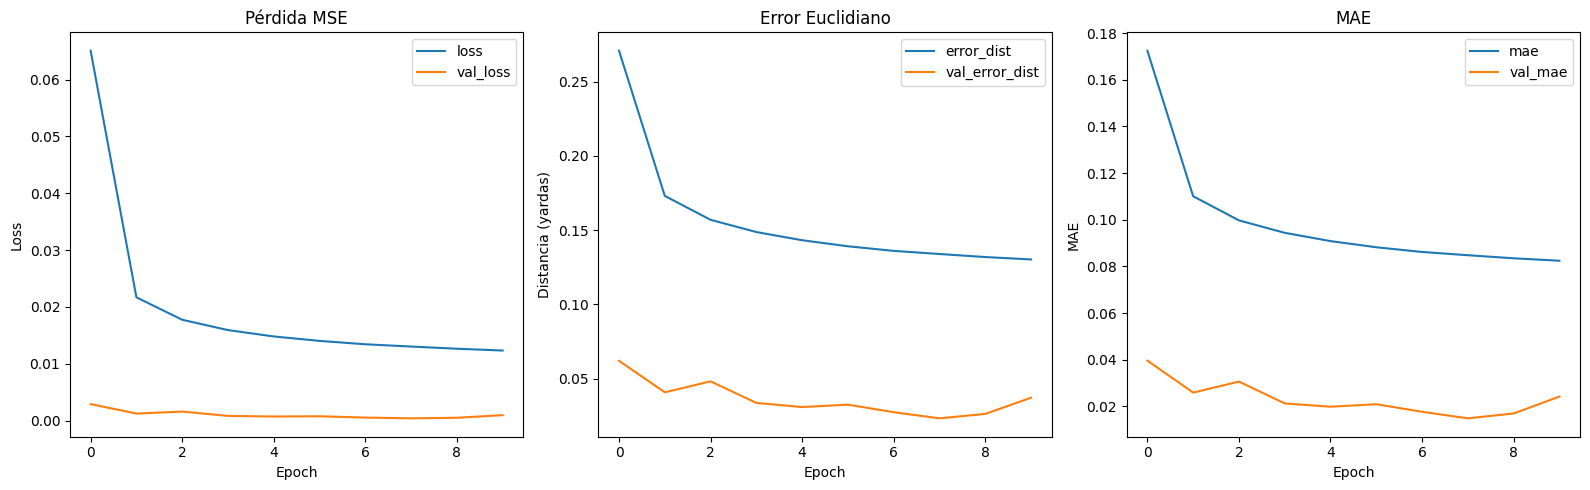

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
Predicciones:
 [[-0.33205885 -0.49381426]
 [-1.1962951  -0.30342403]
 [-0.3382957   0.5926639 ]
 [-0.2569359  -1.2906339 ]
 [ 0.588629    1.1614233 ]]

Valores reales:
 [[-0.31508133 -0.49188198]
 [-1.16996348 -0.29200524]
 [-0.33807119  0.61243701]
 [-0.23461683 -1.28439326]
 [ 0.57939446  1.15810052]]
Errores individuales: [0.01708712 0.02870096 0.0197744  0.02317513 0.00981417]
Error promedio: 0.019710356023305595


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras import backend as K
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import gc
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------
# 1. PREPARACIÓN DE TARGETS (X, Y)
# ---------------------------------------------------------
# Asumo que tu DataFrame 'data' ya tiene todo normalizado excepto quizás los targets.
# Si vas a predecir x, y reales, asegúrate de que 'x' e 'y' en el target
# NO estén normalizados si quieres la predicción en yardas reales, 
# O recuerda des-normalizar la predicción después.

# Definimos las columnas objetivo
target_cols = ['x', 'y']

# Separamos features y targets
# Asumo que 'data' contiene todo. Eliminamos los targets de las features.
X = data.drop(columns=target_cols) 
y = data[target_cols] # y ahora tiene forma (N, 2)

print(f"Features shape: {X.shape}, Target shape: {y.shape}")

# Split (sin shuffle si es una serie temporal estricta, pero con shuffle si son frames independientes)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Limpieza de memoria RAM (Crítico con 4.8M filas)
gc.collect()

# ---------------------------------------------------------
# 2. MÉTRICA PERSONALIZADA: ERROR DE DISTANCIA (Euclidiana)
# ---------------------------------------------------------
def euclidean_distance_error(y_true, y_pred):
    """
    Calcula la distancia promedio entre el punto predicho y el real.
    Útil para saber el error en 'yardas'.
    """
    # Suma de cuadrados de las diferencias
    sum_sq = K.sum(K.square(y_true - y_pred), axis=-1)
    # Raíz cuadrada (Distancia)
    return K.mean(K.sqrt(sum_sq))

# ---------------------------------------------------------
# 3. ARQUITECTURA DE RED (MULTI-OUTPUT)
# ---------------------------------------------------------
def build_spatial_model(input_dim):
    model = models.Sequential()
    
    # --- Entrada ---
    model.add(layers.Input(shape=(input_dim,)))
    
    # --- Bloque Denso 1 (Extracción de características) ---
    model.add(layers.Dense(512)) # Aumentamos neuronas por la complejidad 2D
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))
    
    # --- Bloque Denso 2 ---
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))
    
    # --- Bloque Denso 3 ---
    model.add(layers.Dense(128))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.2))
    
    # --- Salida (2 NEURONAS) ---
    # Una neurona para 'x', otra para 'y'. Activación lineal.
    model.add(layers.Dense(2, activation='linear'))
    
    return model

# Construir modelo
model = build_spatial_model(X_train.shape[1])

# Compilar
# Usamos MSE como Loss para que el gradiente sea estable, 
# pero observamos nuestra métrica de distancia euclidiana para humanos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='mse', 
    metrics=[euclidean_distance_error, 'mae'] 
)

model.summary()

# ---------------------------------------------------------
# 4. ENTRENAMIENTO EN GPU
# ---------------------------------------------------------
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,
    patience=3, 
    min_lr=1e-6
)

# BATCH SIZE GRANDE: Al predecir 2 valores y tener muchos datos,
# subir el batch size ayuda a la estabilidad y velocidad en GPU.
BATCH_SIZE = 2048 

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


# ---------------------------------------------------------
# 1. GRAFICAR PÉRDIDA Y MÉTRICAS
# ---------------------------------------------------------
plt.figure(figsize=(16,5))

# --- Loss ---
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Pérdida MSE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# --- Error euclidiano ---
plt.subplot(1,3,2)
plt.plot(history.history['euclidean_distance_error'], label='error_dist')
plt.plot(history.history['val_euclidean_distance_error'], label='val_error_dist')
plt.title("Error Euclidiano")
plt.xlabel("Epoch")
plt.ylabel("Distancia (yardas)")
plt.legend()

# --- MAE ---
plt.subplot(1,3,3)
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title("MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

# Tomamos algunas muestras del validation set
sample = X_val.iloc[:5]
y_real = y_val.iloc[:5]

y_pred = model.predict(sample)

print("Predicciones:\n", y_pred)
print("\nValores reales:\n", np.array(y_real))

# Error euclidiano manual
errors = np.sqrt(np.sum((y_pred - y_real.values)**2, axis=1))

print("Errores individuales:", errors)
print("Error promedio:", np.mean(errors))


In [22]:
# ============================================================
#   LSTM TRAINING - SEQUENCE MODEL FOR PLAYER TRAJECTORIES
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler
import gc
import time
import matplotlib.pyplot as plt


print("📌 Loading data...")

# ------------------------------------------------------------
# 1. ASSUME data ALREADY EXISTS
# ------------------------------------------------------------
# Your dataset is already loaded as `data`
# Required columns:
#   feature columns
#   target columns = ['ball_land_x', 'ball_land_y']

# ------------------------------------------------------------
# 2. ORDER DATA TEMPORALLY
# ------------------------------------------------------------
print("📌 Sorting data by player and time...")
data = data.sort_values(["player_to_predict", "frame_id"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. FEATURE SET
# ------------------------------------------------------------
target_cols = ["ball_land_x", "ball_land_y"]

feature_cols = [
    # categorical identifiers
    "nfl_id", "player_height", "player_weight", "player_age",

    # positions
    "pos_CB","pos_DE","pos_DT","pos_FB","pos_FS","pos_ILB","pos_MLB","pos_NT",
    "pos_OLB","pos_OTHER","pos_QB","pos_RB","pos_S","pos_SS","pos_TE","pos_WR",

    # roles
    "role_Defensive Coverage","role_Other Route Runner","role_Passer","role_Targeted Receiver",

    # main continuous features
    "absolute_yardline_number","x","y","s","a","dir_x","dir_y","o_x","o_y",
    "angle_diff","v_x","v_y","dist_center","x_norm","y_norm"
]

print(f"🔢 Total features: {len(feature_cols)}")

# ------------------------------------------------------------
# 4. SCALING CONTINUOUS FEATURES
# ------------------------------------------------------------
scaler = StandardScaler()

print("📌 Scaling continuous features...")
data[feature_cols] = scaler.fit_transform(data[feature_cols])

# ------------------------------------------------------------
# 5. GROUP BY PLAYERS FOR SEQUENCE GENERATION
# ------------------------------------------------------------
print("📌 Preparing groups...")
groups = {pid: idx.values for pid, idx in data.groupby("player_to_predict").groups.items()}
players = list(groups.keys())

# LSTM sequence length
seq_len = 20

# ------------------------------------------------------------
# 6. GENERATOR FOR LARGE DATASETS
# ------------------------------------------------------------
print("📌 Building generator...")

def sequence_generator():
    while True:
        for pid in players:
            idxs = groups[pid]
            g = data.loc[idxs]

            if len(g) <= seq_len:
                continue

            X_arr = g[feature_cols].values     # shape (T, F)
            y_arr = g[target_cols].values      # shape (T, 2)

            # Sliding window
            for i in range(len(g) - seq_len):
                X_seq = X_arr[i:i+seq_len]              # (seq_len, features)
                target_vec = y_arr[i+seq_len].astype(np.float32)   # (2,)

                yield X_seq.astype(np.float32), target_vec


# ------------------------------------------------------------
# 7. BUILD TF DATASET
# ------------------------------------------------------------
print("📌 Building tf.data.Dataset...")

dataset = tf.data.Dataset.from_generator(
    sequence_generator,
    output_signature=(
        tf.TensorSpec(shape=(seq_len, len(feature_cols)), dtype=tf.float32),
        tf.TensorSpec(shape=(2,), dtype=tf.float32)
    )
)

batch_size = 512
dataset = dataset.batch(batch_size).prefetch(2)

# Estimate steps per epoch
total_rows = len(data)
steps_per_epoch = min(2000, total_rows // (batch_size * seq_len))
print(f"📌 Using steps_per_epoch = {steps_per_epoch}")

# ------------------------------------------------------------
# 8. MODEL
# ------------------------------------------------------------
print("📌 Building LSTM model...")

model = models.Sequential([
    layers.Input(shape=(seq_len, len(feature_cols))),
    layers.LSTM(128, return_sequences=True),
    layers.LSTM(64),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(2)   # ball_land_x, ball_land_y
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()

# ------------------------------------------------------------
# 9. CALLBACKS
# ------------------------------------------------------------
lr_callback = callbacks.ReduceLROnPlateau(
    monitor="loss", factor=0.25, patience=3, min_lr=1e-6, verbose=1
)

es_callback = callbacks.EarlyStopping(
    monitor="loss", patience=8, restore_best_weights=True, verbose=1
)

# ------------------------------------------------------------
# 10. TRAINING
# ------------------------------------------------------------
print("🚀 Starting training...")
start = time.time()

history = model.fit(
    dataset,
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    callbacks=[lr_callback, es_callback],
    verbose=1
)

print(f"⏱ Training finished in {time.time() - start:.1f} seconds")

# ------------------------------------------------------------
# 11. CLEANUP
# ------------------------------------------------------------
gc.collect()
print("✅ Done.")


# ------------------------------------------------------------
# 12. PLOTEO DE MÉTRICAS
# ------------------------------------------------------------

history_dict = history.history

# Lista automática de todas las métricas registradas
metrics = list(history_dict.keys())
print("📊 Métricas disponibles:", metrics)

# --- Plot de cada métrica ---
for m in metrics:
    plt.figure(figsize=(8, 4))
    plt.plot(history_dict[m], label=m)
    plt.xlabel("Epochs")
    plt.ylabel(m)
    plt.title(f"{m} vs Epochs")
    plt.grid(True)
    plt.legend()
    plt.show()

# Si quieres solo algunos gráficos específicos:
if "loss" in history_dict:
    plt.figure(figsize=(8,4))
    plt.plot(history_dict["loss"])
    plt.title("Loss (MSE) vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

if "mae" in history_dict:
    plt.figure(figsize=(8,4))
    plt.plot(history_dict["mae"])
    plt.title("MAE vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.grid(True)
    plt.show()


📌 Loading data...
📌 Sorting data by player and time...
🔢 Total features: 39
📌 Scaling continuous features...
📌 Preparing groups...
📌 Building generator...
📌 Building tf.data.Dataset...
📌 Using steps_per_epoch = 476
📌 Building LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        86,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,730 (553.63 KB)

 Trainable params: 141,730 (553.63 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Starting training...
Epoch 1/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 67s 130ms/step - loss: 0.5668 - mae: 0.5839 - learning_rate: 0.0010
Epoch 2/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 63s 132ms/step - loss: 0.3778 - mae: 0.4482 - learning_rate: 0.0010
Epoch 3/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 63s 132ms/step - loss: 0.3573 - mae: 0.4315 - learning_rate: 0.0010
Epoch 4/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - loss: 0.3453 - mae: 0.4226 - learning_rate: 0.0010
Epoch 5/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - loss: 0.3307 - mae: 0.4132 - learning_rate: 0.0010
Epoch 6/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 63s 132ms/step - loss: 0.3121 - mae: 0.4005 - learning_rate: 0.0010
Epoch 7/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - loss: 0.2944 - mae: 0.3884 - learning_rate: 0.0010
Epoch 8/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 63s 132ms/step - loss: 0.2755 - mae: 0.3759 - learning_rate: 0.0010
Epoch 9/20
476/476 ━━━━━━━━━━━━━━━━━━━━ 63s 133ms/step - loss: 0.2552 - mae: 0.3624 - learning_rate: 0.0010
Epoch

KeyboardInterrupt: 

steps_per_epoch = 476


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 20, 37)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 20, 128)        │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 20, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 20, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 20, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention_pool_1       │ (None, 128)            │           128 │
│ (TemporalAttentionPool)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 427,330 (1.63 MB)

 Trainable params: 427,330 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - loss: 0.6732 - mae: 0.6446 - learning_rate: 0.0010
Epoch 2/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 62s 130ms/step - loss: 0.5472 - mae: 0.5568 - learning_rate: 0.0010
Epoch 3/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.5366 - mae: 0.5458 - learning_rate: 0.0010
Epoch 4/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - loss: 0.5233 - mae: 0.5330 - learning_rate: 0.0010
Epoch 5/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 61s 128ms/step - loss: 0.5120 - mae: 0.5225 - learning_rate: 0.0010
Epoch 6/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 62s 130ms/step - loss: 0.4953 - mae: 0.5068 - learning_rate: 0.0010
Epoch 7/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 62s 130ms/step - loss: 0.4798 - mae: 0.4938 - learning_rate: 0.0010
Epoch 8/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 61s 128ms/step - loss: 0.4894 - mae: 0.5001 - learning_rate: 0.0010
Epoch 9/25
476/476 ━━━━━━━━━━━━━━━━━━━━ 61s 128ms/step - loss: 0.4999 - mae: 0.5068 - learning_rate: 0.0010
Epoch 10/25
476/476 ━━━━━━━━

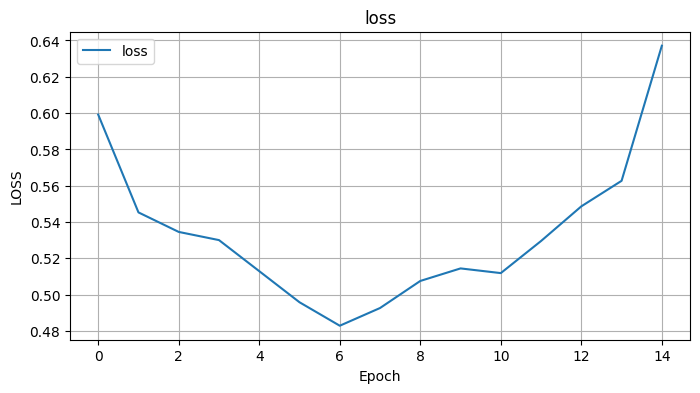

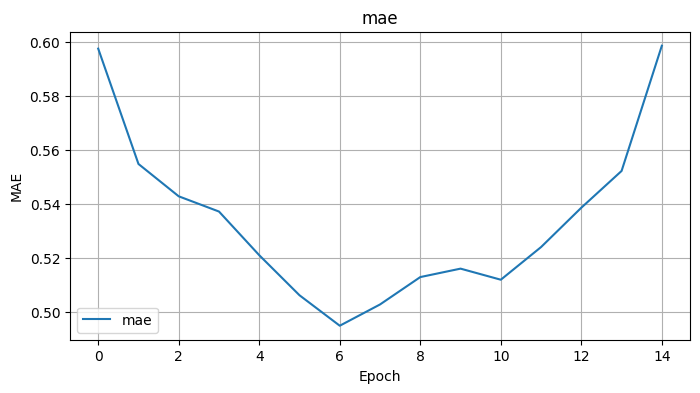

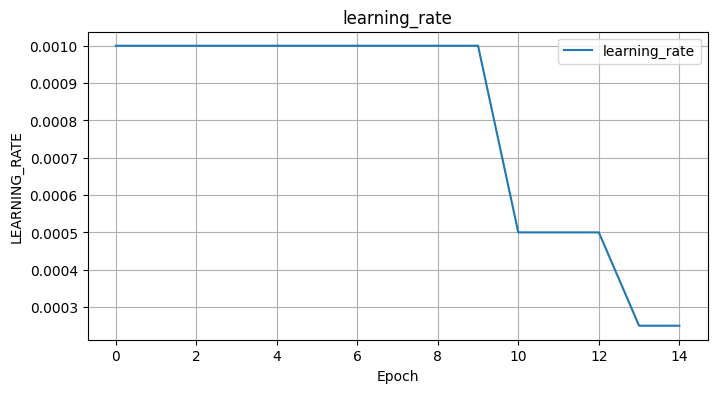

6980

In [24]:
# ============================================================
#   ATTENTION + TAPNET POOLING - PLAYER POSITION PREDICTOR
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import time, gc


# ============================================================
# 1. FEATURE COLUMNS (los que tú diste)
# ============================================================

feature_cols = [
    "nfl_id", 
    "player_height", "player_weight", "player_age",

    "pos_CB","pos_DE","pos_DT","pos_FB","pos_FS","pos_ILB","pos_MLB","pos_NT",
    "pos_OLB","pos_OTHER","pos_QB","pos_RB","pos_S","pos_SS","pos_TE","pos_WR",

    "role_Defensive Coverage","role_Other Route Runner",
    "role_Passer","role_Targeted Receiver",

    "absolute_yardline_number","s","a","dir_x","dir_y","o_x","o_y",
    "angle_diff","v_x","v_y","dist_center","x_norm","y_norm"
]

target_cols = ["x", "y"]


# ============================================================
# 2. AGRUPAR POR JUGADOR PARA GENERAR SECUENCIAS
# ============================================================

seq_len = 20
players = list(data.groupby("player_to_predict").groups.keys())
groups = {pid: idx.values for pid, idx in data.groupby("player_to_predict").groups.items()}


def sequence_generator():
    while True:
        for pid in players:
            idxs = groups[pid]
            g = data.loc[idxs]

            if len(g) <= seq_len:
                continue

            X_arr = g[feature_cols].values.astype(np.float32)
            y_arr = g[target_cols].values.astype(np.float32)

            for i in range(len(g) - seq_len):
                yield (
                    X_arr[i:i+seq_len],       # (seq, features)
                    y_arr[i+seq_len]          # (x,y)
                )


output_signature = (
    tf.TensorSpec(shape=(seq_len, len(feature_cols)), dtype=tf.float32),
    tf.TensorSpec(shape=(2,), dtype=tf.float32)
)

batch_size = 512

dataset = tf.data.Dataset.from_generator(sequence_generator, output_signature=output_signature)
dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

steps_per_epoch = min(2000, len(data) // (batch_size * seq_len))
print("steps_per_epoch =", steps_per_epoch)


# ============================================================
# 3. TAPNET + TRANSFORMER MODEL
# ============================================================

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model)
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

    def call(self, x):
        attn_out = self.att(x, x)
        x = self.norm1(x + attn_out)
        ff_out = self.ffn(x)
        return self.norm2(x + ff_out)


class TemporalAttentionPool(layers.Layer):
    """ TAP-like pooling: un query entrenable atiende sobre el tiempo """
    def __init__(self, d_model):
        super().__init__()
        self.query = self.add_weight(shape=(1, d_model), initializer="glorot_uniform", trainable=True)

    def call(self, x):
        # x: (batch, seq_len, d_model)
        q = tf.expand_dims(self.query, axis=0)        # (1,1,d)
        q = tf.tile(q, [tf.shape(x)[0], 1, 1])        # (batch,1,d)

        scores = tf.matmul(q, x, transpose_b=True)    # (batch,1,seq)
        att = tf.nn.softmax(scores, axis=-1)          # (batch,1,seq)

        pooled = tf.matmul(att, x)                    # (batch,1,d)
        return tf.squeeze(pooled, axis=1)             # (batch,d)


# ============================================================
# 4. BUILD MODEL
# ============================================================

d_model = 128
num_heads = 4
ff_dim  = 256
layers_enc = 3

inp = layers.Input(shape=(seq_len, len(feature_cols)))

# Proyección inicial
x = layers.Dense(d_model)(inp)

# Positional embedding simple
positions = tf.range(seq_len)
pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)(positions)
pos_emb = tf.expand_dims(pos_emb, 0)
x = x + pos_emb

# Transformer Encoders
for _ in range(layers_enc):
    x = TransformerBlock(d_model, num_heads, ff_dim)(x)

# TAP pooling
x = TemporalAttentionPool(d_model)(x)

# MLP head
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(2)(x)

model = tf.keras.Model(inp, out)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"]
)

model.summary()


# ============================================================
# 5. TRAINING
# ============================================================

callbacks_list = [
    callbacks.ReduceLROnPlateau(monitor="loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="loss", patience=8, restore_best_weights=True, verbose=1)
]

start = time.time()
history = model.fit(dataset, steps_per_epoch=steps_per_epoch, epochs=25, callbacks=callbacks_list)
print("Training time:", time.time() - start)


# ============================================================
# 6. GRÁFICAS DE MÉTRICAS
# ============================================================

hist = history.history

for metric_name, values in hist.items():
    plt.figure(figsize=(8, 4))
    plt.plot(values, label=metric_name)
    plt.title(metric_name)
    plt.xlabel("Epoch")
    plt.ylabel(metric_name.upper())
    plt.grid()
    plt.legend()
    plt.show()

gc.collect()
